In [1]:
import pandas as pd
import numpy as np
import pyseaflux
from functools import reduce

# ============================================================
# CONSTANTS / PATHS
# ============================================================

SOCAT_SIGMA = 5.0
AREA_CSV = "/remote/unity/bgc-output/DELAIGUE/SOCAT-FLOATS-OSSE/data/ocean_mask/ocean_area_south_of_30S.csv"

PATHS = {
    "socat_obs": "/remote/unity/bgc-output/DELAIGUE/SOCAT-FLOATS-OSSE/MODEL_SOCAT_ONLY_OBS_v2/processing_steps/SOCATv2025_SO_feature_engineered_monthly_1deg_pCO2.csv",
    "socat_pred": "/remote/unity/bgc-output/DELAIGUE/SOCAT-FLOATS-OSSE/PREDICTION_MATRIX_v2/matrix_predictions/pco2_prediction_matrix_SOCAT_only_MCensemble.csv",
    "floats_obs": "/remote/unity/bgc-output/DELAIGUE/SOCAT-FLOATS-OSSE/MODEL_FLOATS_v2/processing_steps/BGC-Argo_SO_feature_engineered_monthly_1deg.csv",
    "floats_pred": "/remote/unity/bgc-output/DELAIGUE/SOCAT-FLOATS-OSSE/PREDICTION_MATRIX_v2/matrix_predictions/pco2_prediction_matrix_FLOATS_only_MCensemble.csv",
    "combined_obs": "/remote/unity/bgc-output/DELAIGUE/SOCAT-FLOATS-OSSE/MODEL_SOCAT_AND_FLOATS_v2/processing_steps/pco2_all_splits_combined.csv",
    "combined_pred_weighted": "/remote/unity/bgc-output/DELAIGUE/SOCAT-FLOATS-OSSE/PREDICTION_MATRIX_v2/matrix_predictions/pco2_prediction_matrix_SOCAT_AND_FLOATS_weighted_MCensemble.csv",
}

# ============================================================
# GRID / AREA WEIGHTING
# ============================================================

R = 6371000
DEG2RAD = np.pi / 180

lat_centers = np.arange(-89.5, 90.5, 1)[:-1]
band_areas = 2 * np.pi * R**2 * (
    np.sin((lat_centers + 0.5) * DEG2RAD) - np.sin((lat_centers - 0.5) * DEG2RAD)
)
cell_area_by_lat = pd.Series(band_areas / 360, index=np.arange(-89, 90, 1))


def bin_flux(df, lat_col, lon_col, time_col, flux_col):
    out = df.copy()
    out["lat_bin"] = out[lat_col].astype(int)
    out["lon_bin"] = out[lon_col].astype(int)
    out["year"] = out[time_col].dt.year
    out["month"] = out[time_col].dt.month

    return (
        out.groupby(["lat_bin", "lon_bin", "year", "month"], as_index=False)[flux_col]
        .mean()
        .rename(columns={flux_col: "mean_flux"})
    )


def area_weighted_monthly_mean(binned):
    df = binned.merge(
        cell_area_by_lat.rename("cell_area_m2"),
        left_on="lat_bin",
        right_index=True,
        how="left",
    )
    df["weighted_flux"] = df["mean_flux"] * df["cell_area_m2"]

    out = (
        df.groupby(["year", "month"], as_index=False)
        .agg(
            total_flux=("weighted_flux", "sum"),
            total_area=("cell_area_m2", "sum"),
        )
    )
    out["aw_mean_flux"] = out["total_flux"] / out["total_area"]
    out["date"] = pd.to_datetime(dict(year=out["year"], month=out["month"], day=15))

    return out[["year", "month", "date", "aw_mean_flux"]]


# ============================================================
# FLUX
# ============================================================

def flux_from_pco2(
    df,
    temp_col,
    sal_col,
    pco2_col,
    wind_col="wind_speed",
    air_col="atm_co2",
):
    temp = df[temp_col].to_numpy()
    sal = df[sal_col].to_numpy()
    pco2_sw = df[pco2_col].to_numpy()
    wind = df[wind_col].to_numpy()
    air = df[air_col].to_numpy()

    pres = 1013.25
    k_w = pyseaflux.gas_transfer_velocity.k_Ho06(wind, temp)
    flux_mol = pyseaflux.flux_calculations.flux_bulk(temp, sal, pco2_sw, air, pres, k_w)

    return flux_mol * 12.01


# ============================================================
# UNCERTAINTY HELPERS
# ============================================================

def make_obs_bounds(df, value_col, sigma):
    low = df.copy()
    high = df.copy()

    if isinstance(sigma, str):
        sigma_values = df[sigma]
    elif np.isscalar(sigma):
        sigma_values = sigma
    else:
        raise TypeError("sigma must be either a numeric scalar or a column name")

    low[value_col] = low[value_col] - sigma_values
    high[value_col] = high[value_col] + sigma_values
    return low, high


def make_pred_bounds(df, pred_col="ensemble_pco2_pred", sigma_col="ensemble_pco2_std"):
    low = df.copy()
    high = df.copy()

    low[pred_col] = low[pred_col] - df[sigma_col]
    high[pred_col] = high[pred_col] + df[sigma_col]
    return low, high


# ============================================================
# SERIES PIPELINE
# ============================================================

def monthly_flux_series(
    df,
    *,
    temp_col,
    sal_col,
    pco2_col,
    lat_col,
    lon_col,
    time_col="month_center",
    series_name,
):
    out = df.copy()
    out["time"] = pd.to_datetime(out[time_col])
    out["flux_month"] = (
        flux_from_pco2(
            out,
            temp_col=temp_col,
            sal_col=sal_col,
            pco2_col=pco2_col,
        )
        * out["time"].dt.days_in_month
    )

    out = area_weighted_monthly_mean(
        bin_flux(
            out,
            lat_col=lat_col,
            lon_col=lon_col,
            time_col="time",
            flux_col="flux_month",
        )
    )

    return out.rename(columns={"aw_mean_flux": series_name})


def bounded_monthly_flux(
    base_df,
    low_df,
    high_df,
    *,
    temp_col,
    sal_col,
    pco2_col,
    lat_col,
    lon_col,
    prefix,
    time_col="month_center",
):
    return [
        monthly_flux_series(
            base_df,
            temp_col=temp_col,
            sal_col=sal_col,
            pco2_col=pco2_col,
            lat_col=lat_col,
            lon_col=lon_col,
            time_col=time_col,
            series_name=prefix,
        ),
        monthly_flux_series(
            low_df,
            temp_col=temp_col,
            sal_col=sal_col,
            pco2_col=pco2_col,
            lat_col=lat_col,
            lon_col=lon_col,
            time_col=time_col,
            series_name=f"{prefix}_low",
        ),
        monthly_flux_series(
            high_df,
            temp_col=temp_col,
            sal_col=sal_col,
            pco2_col=pco2_col,
            lat_col=lat_col,
            lon_col=lon_col,
            time_col=time_col,
            series_name=f"{prefix}_high",
        ),
    ]


def merge_on_date(frames):
    return reduce(
        lambda left, right: left.merge(right, on=["year", "month", "date"]),
        frames,
    )


def scale_flux_columns(df, ocean_area_m2, exclude=("year", "month", "date")):
    out = df.copy()
    flux_cols = [col for col in out.columns if col not in exclude]
    out[flux_cols] = out[flux_cols] * 12 * ocean_area_m2 / 1e15
    return out


def add_sigma_column(df, base_name):
    out = df.copy()
    out[f"{base_name}_sigma_PgC_yr"] = 0.5 * (
        out[f"{base_name}_high"] - out[f"{base_name}_low"]
    )
    return out


def yearly_summary(df, value_cols):
    return df.groupby("year", as_index=False)[value_cols].mean()


# ============================================================
# LOAD DATA
# ============================================================

predictions_socat = pd.read_csv(PATHS["socat_pred"])
socat_df = pd.read_csv(PATHS["socat_obs"], low_memory=False)

predictions_floats = pd.read_csv(PATHS["floats_pred"])
floats_df = pd.read_csv(PATHS["floats_obs"], low_memory=False).rename(
    columns={"pco2": "FLOATS_pco2_median"}
)

predictions_combined_weighted = pd.read_csv(PATHS["combined_pred_weighted"])
combined_df = pd.read_csv(PATHS["combined_obs"], low_memory=False)

print("Loading ocean area south of 30°S...")
OCEAN_AREA_M2 = pd.read_csv(AREA_CSV)["ocean_area_m2"].iloc[0]
print(f"Using OCEAN_AREA_M2 = {OCEAN_AREA_M2:.3e} m²")


# ============================================================
# BUILD UNCERTAINTY DATAFRAMES
# ============================================================

socat_df_low, socat_df_high = make_obs_bounds(
    socat_df,
    value_col="pco2",
    sigma=SOCAT_SIGMA,
)

floats_df_low, floats_df_high = make_obs_bounds(
    floats_df,
    value_col="FLOATS_pco2_median",
    sigma="FLOATS_pco2_error_median",
)

combined_df_low, combined_df_high = make_obs_bounds(
    combined_df,
    value_col="pco2",
    sigma="uncertainty_pco2",
)

pred_socat_low, pred_socat_high = make_pred_bounds(predictions_socat)
pred_floats_low, pred_floats_high = make_pred_bounds(predictions_floats)
pred_combined_weighted_low, pred_combined_weighted_high = make_pred_bounds(
    predictions_combined_weighted
)


# ============================================================
# MONTHLY SERIES
# ============================================================

monthly_frames = []

monthly_frames += bounded_monthly_flux(
    socat_df,
    socat_df_low,
    socat_df_high,
    temp_col="SOCAT_temperature",
    sal_col="SOCAT_salinity",
    pco2_col="pco2",
    lat_col="lat_center",
    lon_col="lon_center",
    prefix="SOCAT",
)

monthly_frames += bounded_monthly_flux(
    predictions_socat,
    pred_socat_low,
    pred_socat_high,
    temp_col="SOCAT_temperature",
    sal_col="SOCAT_salinity",
    pco2_col="ensemble_pco2_pred",
    lat_col="latitude",
    lon_col="longitude",
    prefix="SOCAT_predictions",
)

monthly_frames += bounded_monthly_flux(
    floats_df,
    floats_df_low,
    floats_df_high,
    temp_col="FLOATS_temperature_median",
    sal_col="FLOATS_salinity_median",
    pco2_col="FLOATS_pco2_median",
    lat_col="lat_center",
    lon_col="lon_center",
    prefix="floats",
)

monthly_frames += bounded_monthly_flux(
    predictions_floats,
    pred_floats_low,
    pred_floats_high,
    temp_col="FLOATS_temperature_median",
    sal_col="FLOATS_salinity_median",
    pco2_col="ensemble_pco2_pred",
    lat_col="lat_center",
    lon_col="lon_center",
    prefix="floats_predictions",
)

monthly_frames += bounded_monthly_flux(
    combined_df,
    combined_df_low,
    combined_df_high,
    temp_col="temperature",
    sal_col="salinity",
    pco2_col="pco2",
    lat_col="latitude",
    lon_col="longitude",
    prefix="combined",
)

monthly_frames += bounded_monthly_flux(
    predictions_combined_weighted,
    pred_combined_weighted_low,
    pred_combined_weighted_high,
    temp_col="ARMOR3D_temperature",
    sal_col="ARMOR3D_salinity",
    pco2_col="ensemble_pco2_pred",
    lat_col="latitude",
    lon_col="longitude",
    prefix="combined_predictions_weighted",
)

monthly_flux_summary = merge_on_date(monthly_frames)
monthly_flux_summary = scale_flux_columns(monthly_flux_summary, OCEAN_AREA_M2)


# ============================================================
# SIGMAS
# ============================================================

for name in [
    "SOCAT",
    "SOCAT_predictions",
    "floats",
    "floats_predictions",
    "combined",
    "combined_predictions_weighted",
]:
    monthly_flux_summary = add_sigma_column(monthly_flux_summary, name)


# ============================================================
# YEARLY SUMMARIES
# ============================================================

yearly_cols = [
    "SOCAT",
    "SOCAT_sigma_PgC_yr",
    "SOCAT_predictions",
    "SOCAT_predictions_sigma_PgC_yr",
    "floats",
    "floats_sigma_PgC_yr",
    "floats_predictions",
    "floats_predictions_sigma_PgC_yr",
    "combined",
    "combined_sigma_PgC_yr",
    "combined_predictions_weighted",
    "combined_predictions_weighted_sigma_PgC_yr",
]

yearly_flux_summary = yearly_summary(monthly_flux_summary, yearly_cols)

mask = yearly_flux_summary["year"].between(2003, 2024)
mean_vals = yearly_flux_summary.loc[mask].mean(numeric_only=True)

Loading ocean area south of 30°S...
Using OCEAN_AREA_M2 = 1.101e+14 m²


# Figure 4

/tmp/ipykernel_2239865/1192526995.py:215: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(rect=[0, 0.10, 1, 1])


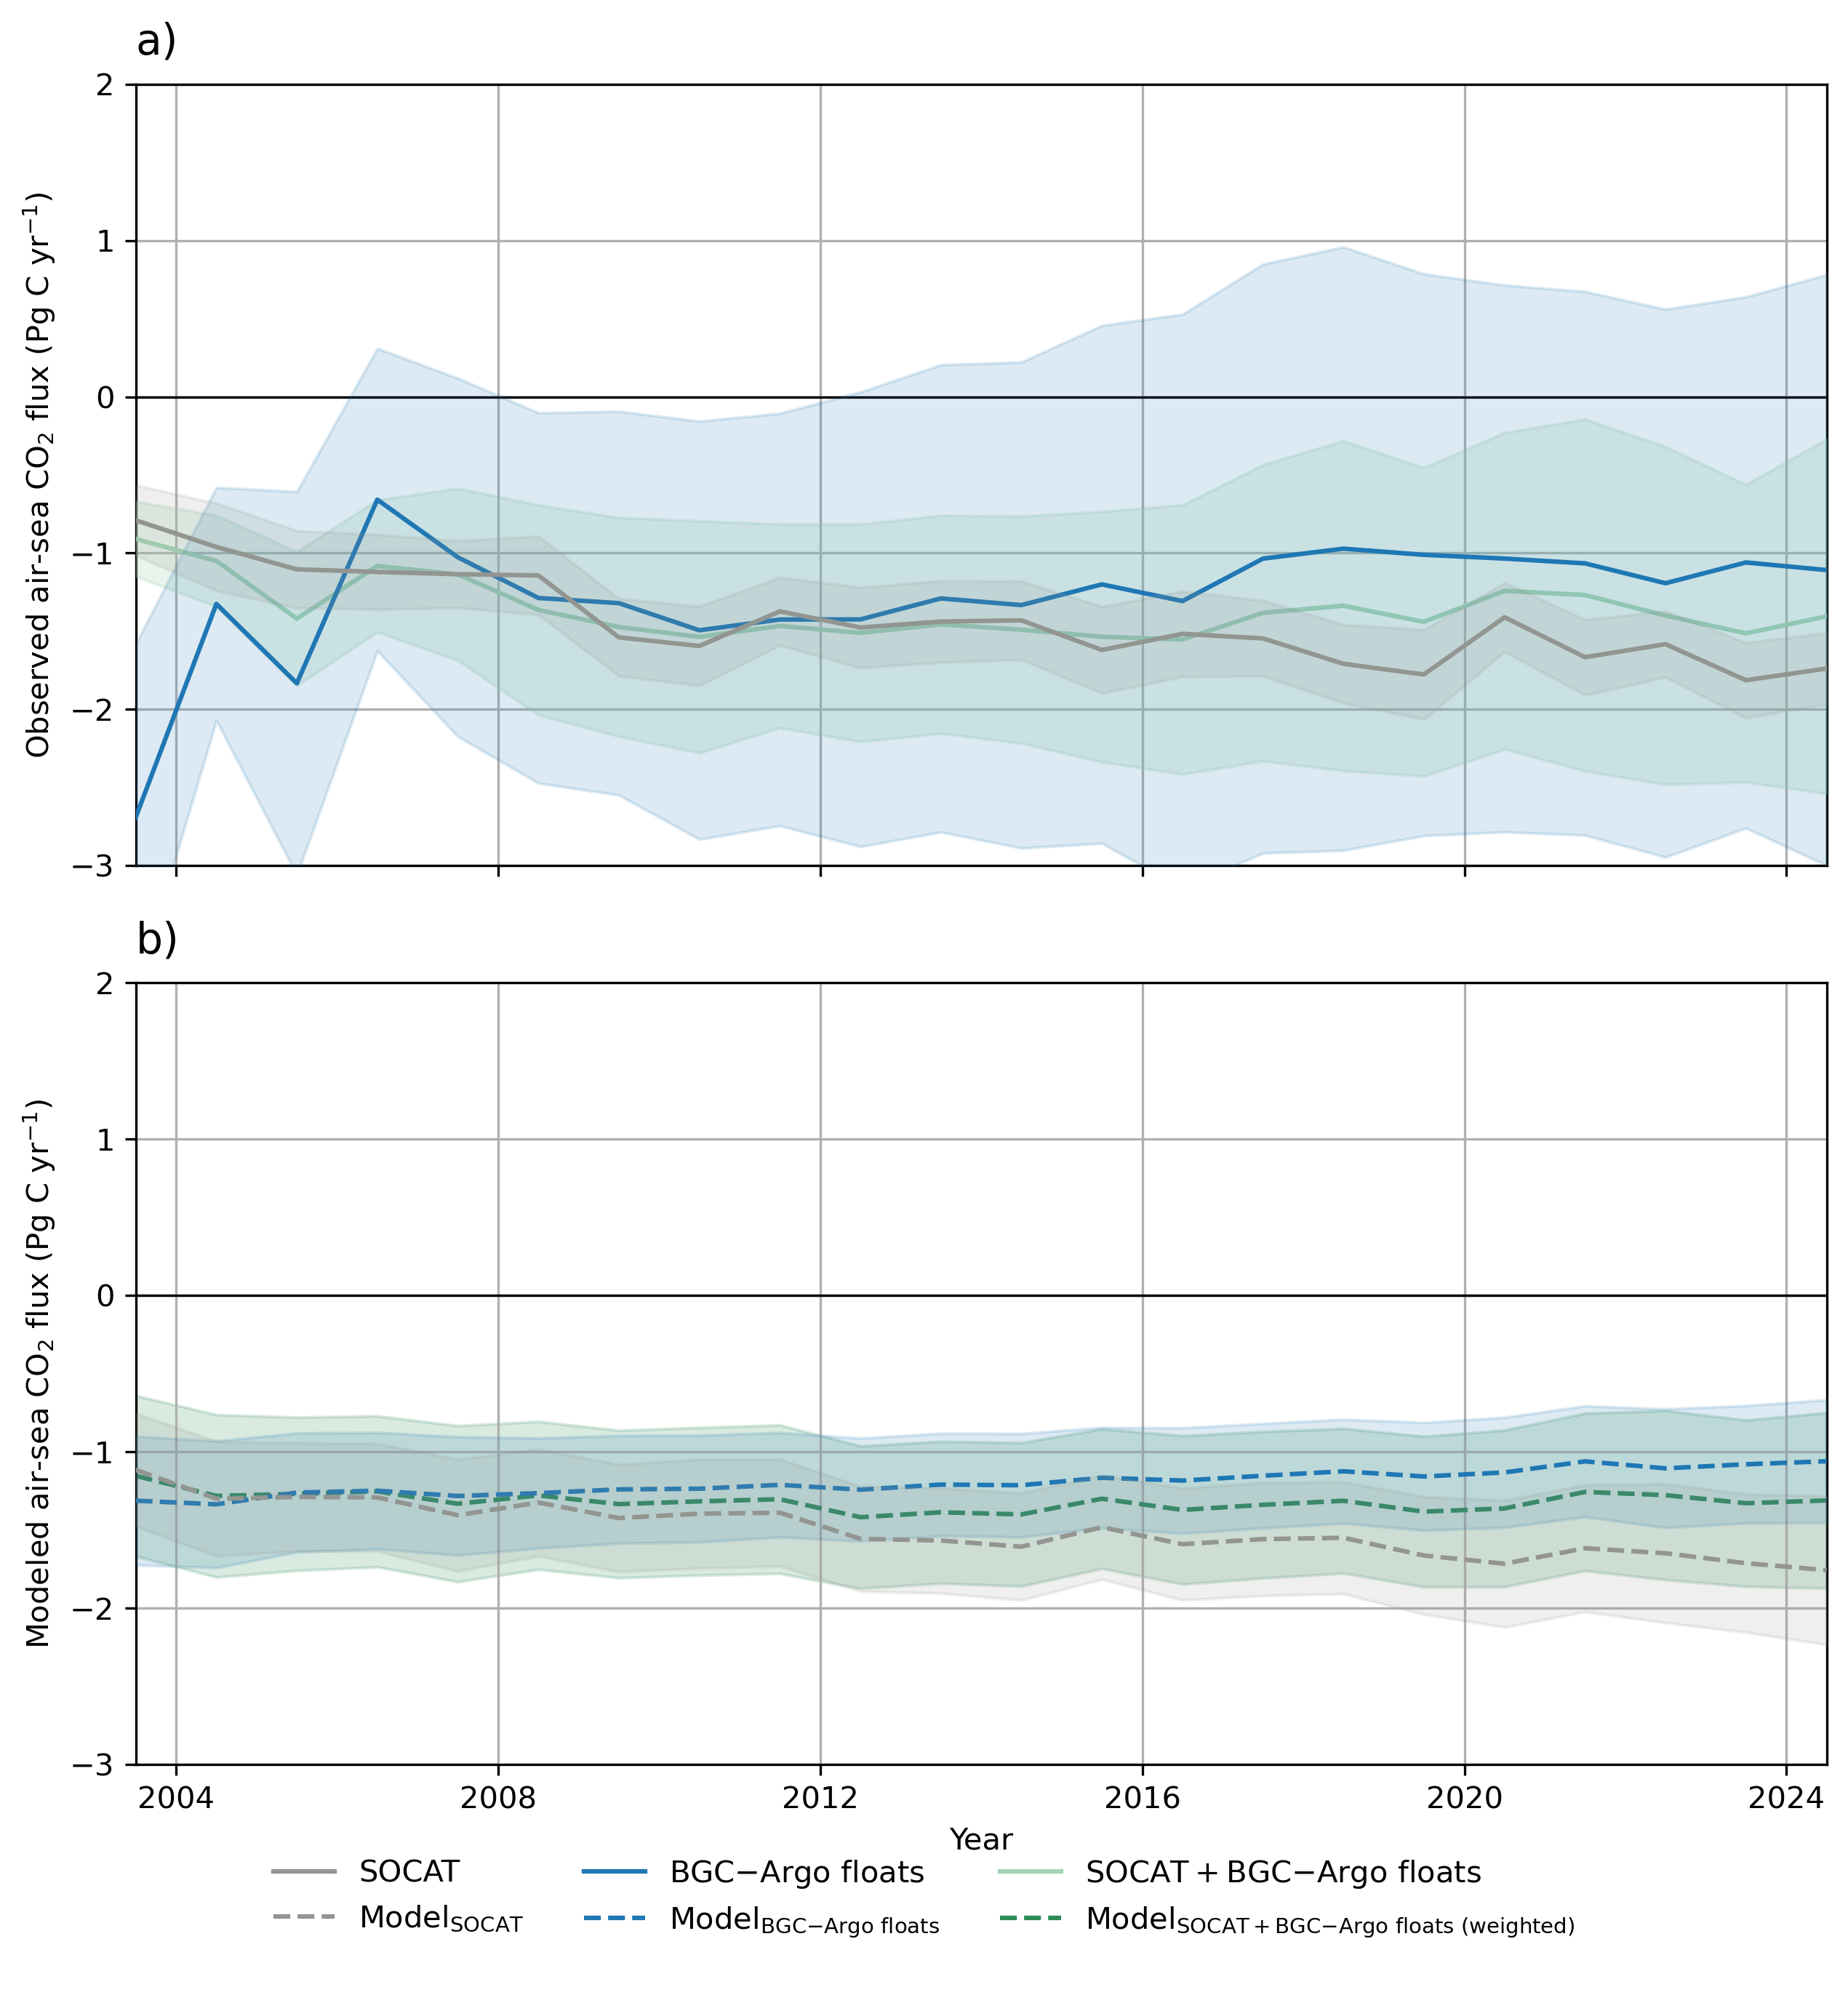

In [2]:
# ============================================================
# Figure 4. Annual air-sea CO2 fluxes with ±1 sigma uncertainty
# SOCAT, BGC-Argo floats, and combined product
# ============================================================

import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

FIG4_PATH = (
    "/remote/unity/bgc-output/DELAIGUE/SOCAT-FLOATS-OSSE/figs/"
    "Fig4.png"
)

YLIM = (-3, 2)

OBS_SERIES = [
    {
        "value": "SOCAT",
        "sigma": "SOCAT_sigma_PgC_yr",
        "label": "SOCAT",
        "plot_label": "SOCATv2025",
        "color": "#929591",
        "linestyle": "-",
        "alpha": 0.15,
        "zorder": 8,
    },
    {
        "value": "floats",
        "sigma": "floats_sigma_PgC_yr",
        "label": r"$\mathrm{BGC{-}Argo\ floats}$",
        "plot_label": r"$\mathrm{BGC{-}Argo\ floats}$",
        "color": "tab:blue",
        "linestyle": "-",
        "alpha": 0.15,
        "zorder": 6,
    },
    {
        "value": "combined",
        "sigma": "combined_sigma_PgC_yr",
        "label": r"$\mathrm{SOCAT+BGC{-}Argo\ floats}$",
        "plot_label": r"$\mathrm{SOCAT+BGC{-}Argo\ floats}$",
        "color": "#A4D4B4",
        "linestyle": "-",
        "alpha": 0.25,
        "zorder": 4,
    },
]

MODEL_SERIES = [
    {
        "value": "SOCAT_predictions",
        "sigma": "SOCAT_predictions_sigma_PgC_yr",
        "label": r"Model$_{\mathrm{SOCAT}}$",
        "plot_label": r"Model$_{\mathrm{SOCATv2025}}$",
        "color": "#929591",
        "linestyle": "--",
        "alpha": 0.15,
        "zorder": 8,
    },
    {
        "value": "floats_predictions",
        "sigma": "floats_predictions_sigma_PgC_yr",
        "label": r"Model$_{\mathrm{BGC{-}Argo\ floats}}$",
        "plot_label": r"Model$_{\mathrm{BGC{-}Argo\ floats}}$",
        "color": "tab:blue",
        "linestyle": "--",
        "alpha": 0.15,
        "zorder": 6,
    },
    {
        "value": "combined_predictions_weighted",
        "sigma": "combined_predictions_weighted_sigma_PgC_yr",
        "label": r"Model$_{\mathrm{SOCAT+BGC{-}Argo\ floats\ (weighted)}}$",
        "plot_label": r"Model$_{\mathrm{SOCAT+BGC{-}Argo\ floats\ (weighted)}}$",
        "color": "#2E8B57",
        "linestyle": "--",
        "alpha": 0.18,
        "zorder": 2,
    },
]


def add_year_center(df, year_col="year"):
    out = df.copy()
    out["year_center"] = pd.to_datetime(out[year_col].astype(str) + "-07-01")
    return out


def plot_with_uncertainty(ax, df, x_col, cfg, lw=1.5):
    x = df[x_col]
    y = df[cfg["value"]]
    s = df[cfg["sigma"]]

    line, = ax.plot(
        x,
        y,
        color=cfg["color"],
        linestyle=cfg["linestyle"],
        lw=lw,
        zorder=cfg["zorder"],
        label=cfg["plot_label"],
    )

    ax.fill_between(
        x,
        y - s,
        y + s,
        color=cfg["color"],
        alpha=cfg["alpha"],
        zorder=cfg["zorder"] - 1,
    )
    return line


def style_panel(ax, ylabel, panel_label, ylim=YLIM, xlabel=None):
    ax.set_ylabel(ylabel)
    if xlabel is not None:
        ax.set_xlabel(xlabel)

    ax.grid(True)
    ax.axhline(0, color="k", lw=0.8)
    ax.set_ylim(*ylim)

    ax.text(
        0,
        1.08,
        panel_label,
        transform=ax.transAxes,
        fontsize=14,
        va="top",
        ha="left",
    )


# ------------------------------------------------------------
# Prepare plotting dataframe
# ------------------------------------------------------------

plot_df = add_year_center(yearly_flux_summary)

xmin = plot_df["year_center"].min()
xmax = plot_df["year_center"].max()

# ------------------------------------------------------------
# Build figure
# ------------------------------------------------------------

fig, (ax1, ax2) = plt.subplots(
    2,
    1,
    figsize=(10, 10),
    dpi=300,
    sharex=True,
    gridspec_kw={"hspace": 0.15},
)

obs_lines = [
    plot_with_uncertainty(ax1, plot_df, "year_center", cfg)
    for cfg in OBS_SERIES
]

model_lines = [
    plot_with_uncertainty(ax2, plot_df, "year_center", cfg)
    for cfg in MODEL_SERIES
]

style_panel(
    ax1,
    ylabel="Observed air-sea CO$_2$ flux (Pg C yr$^{-1}$)",
    panel_label="a)",
)

style_panel(
    ax2,
    ylabel="Modeled air-sea CO$_2$ flux (Pg C yr$^{-1}$)",
    panel_label="b)",
    xlabel="Year",
)

ax1.set_xlim(xmin, xmax)
ax2.set_xlim(xmin, xmax)

# ------------------------------------------------------------
# Legend
# ------------------------------------------------------------

blank = Line2D([], [], linestyle="none", marker=None, alpha=0)

handles = [
    obs_lines[0], model_lines[0], blank,
    obs_lines[1], model_lines[1], blank,
    obs_lines[2], model_lines[2],
]

labels = [
    OBS_SERIES[0]["label"],
    MODEL_SERIES[0]["label"],
    "",
    OBS_SERIES[1]["label"],
    MODEL_SERIES[1]["label"],
    "",
    OBS_SERIES[2]["label"],
    MODEL_SERIES[2]["label"],
]

fig.legend(
    handles,
    labels,
    loc="lower center",
    ncol=3,
    frameon=False,
)

fig.tight_layout(rect=[0, 0.10, 1, 1])
fig.savefig(FIG4_PATH, dpi=300, bbox_inches="tight")
plt.show()

## Uncertainty difference from panel a to panel b

In [3]:
import numpy as np
import pandas as pd

YEAR_MIN, YEAR_MAX = 2003, 2024

SIGMA_PAIRS = {
    "SOCAT: obs → model": (
        "SOCAT_sigma_PgC_yr",
        "SOCAT_predictions_sigma_PgC_yr",
    ),
    "FLOATS: obs → model": (
        "floats_sigma_PgC_yr",
        "floats_predictions_sigma_PgC_yr",
    ),
    "COMBINED (weighted): obs → model": (
        "combined_sigma_PgC_yr",
        "combined_predictions_weighted_sigma_PgC_yr",
    ),
}


def restrict_years(df, year_min=YEAR_MIN, year_max=YEAR_MAX):
    return df.loc[df["year"].between(year_min, year_max)].copy()


def clean_sigma_pair(df, obs_col, model_col):
    out = (
        df[["year", obs_col, model_col]]
        .replace([np.inf, -np.inf], np.nan)
        .dropna()
    )
    return out.loc[(out[obs_col] > 0) & (out[model_col] >= 0)].copy()


def summarize_sigma_pair(df, label, obs_col, model_col):
    tmp = clean_sigma_pair(df, obs_col, model_col)

    sigma_obs = tmp[obs_col].to_numpy()
    sigma_mod = tmp[model_col].to_numpy()
    pct_change = 100.0 * (sigma_mod - sigma_obs) / sigma_obs

    return {
        "pair": label,
        "n_years": len(tmp),
        "median_sigma_obs": np.median(sigma_obs),
        "median_sigma_model": np.median(sigma_mod),
        "median_pct_change": np.median(pct_change),
        "mean_sigma_obs": np.mean(sigma_obs),
        "mean_sigma_model": np.mean(sigma_mod),
        "mean_pct_change": np.mean(pct_change),
    }


def build_sigma_summary(df, sigma_pairs):
    rows = [
        summarize_sigma_pair(df, label, obs_col, model_col)
        for label, (obs_col, model_col) in sigma_pairs.items()
    ]
    return pd.DataFrame(rows)


def print_sigma_summary(summary_df, year_min=YEAR_MIN, year_max=YEAR_MAX):
    print(f"\n=== Annual ±1σ envelope comparison ({year_min}–{year_max}) ===\n")

    for _, row in summary_df.iterrows():
        direction = "reduction" if row["median_pct_change"] < 0 else "increase"
        print(
            f"{row['pair']} (n={int(row['n_years'])}): "
            f"median σobs={row['median_sigma_obs']:.2f}, "
            f"median σmodel={row['median_sigma_model']:.2f} Pg C yr⁻¹; "
            f"median change={row['median_pct_change']:+.1f}% ({direction})"
        )

    print("\n--- Full table ---")
    print(summary_df.to_string(index=False))


# ============================================================
# RUN
# ============================================================

analysis_df = restrict_years(yearly_flux_summary, YEAR_MIN, YEAR_MAX)
paper = build_sigma_summary(analysis_df, SIGMA_PAIRS)

print_sigma_summary(paper, YEAR_MIN, YEAR_MAX)


=== Annual ±1σ envelope comparison (2003–2024) ===

SOCAT: obs → model (n=22): median σobs=0.25, median σmodel=0.36 Pg C yr⁻¹; median change=+41.4% (increase)
FLOATS: obs → model (n=22): median σobs=1.52, median σmodel=0.35 Pg C yr⁻¹; median change=-78.0% (reduction)
COMBINED (weighted): obs → model (n=22): median σobs=0.73, median σmodel=0.48 Pg C yr⁻¹; median change=-36.5% (reduction)

--- Full table ---
                            pair  n_years  median_sigma_obs  median_sigma_model  median_pct_change  mean_sigma_obs  mean_sigma_model  mean_pct_change
              SOCAT: obs → model       22          0.246818            0.357823          41.422452        0.246079          0.369570        51.835572
             FLOATS: obs → model       22          1.524912            0.348781         -77.972525        1.486491          0.356341       -74.275912
COMBINED (weighted): obs → model       22          0.734312            0.478633         -36.531091        0.762770          0.488457       

# Global Carbon Budget processing

## GCB fCO₂-Based Southern Ocean fluxes (<30°S)

In [5]:
import xarray as xr
import numpy as np
import pandas as pd
import glob

path_gcb = "/remote/unity/bgc-output/DELAIGUE/SOCAT-FLOATS-OSSE/data/GCB/Ocean/"
fco2_files = sorted(glob.glob(path_gcb + "GCB-2025_dataprod_*.nc"))

south_list = []
product_names = []
bad_files = []

for f in fco2_files:
    try:
        ds = xr.open_dataset(f)

        if "fgco2_reg" not in ds:
            raise ValueError("fgco2_reg missing")

        # SOUTH = region index 3 (<30°S)
        south = ds["fgco2_reg"][:, 3].to_series()

        # =============== FIX FOR JENA-MLS VS MONTHLY PRODUCTS ===============
        if len(south) == len(ds["time"]):
            # Normal monthly product → resample
            south.index = pd.to_datetime(ds["time"].values)
            south_ann = south.resample("YE").mean()
        else:
            # Already annual (e.g. JENA-MLS)
            start_year = int(ds["time"].dt.year.min())
            years = np.arange(start_year, start_year + len(south))
            south_ann = south.copy()
            south_ann.index = pd.to_datetime(years, format="%Y")

        # =============== APPLY GCB SOUTH RIVER CORRECTION ====================
        south_ann = south_ann + 0.09   # Pg C yr-1

        # =============== CONVERT TO SIGN CONVENTION ====================
        south_ann = -south_ann        # NEGATIVE = sink

        # =============== RESTRICT TO ANALYSIS PERIOD ===================
        south_ann = south_ann[
            (south_ann.index.year >= 2003) &
            (south_ann.index.year <= 2024)
        ]

        south_list.append(south_ann.values)
        product_names.append(ds.attrs.get("model_name", f.split("/")[-1]))

        print("Loaded:", f.split("/")[-1])

    except Exception as e:
        print("FAILED:", f.split("/")[-1])
        print("   Reason:", str(e))
        bad_files.append(f)

# ===================== BUILD FINAL DATASET =====================

years = south_ann.index.year

fco2_ds = xr.Dataset(
    data_vars=dict(
        fgco2_products=(["product", "year"], np.vstack(south_list))
    ),
    coords=dict(
        product=("product", product_names),
        year=("year", years)
    ),
    attrs=dict(
        description="GCB 2025 fCO2-based products, South <30°S, annual mean",
        time_period="2003–2024",
        units="Pg C yr-1",
        sign_convention="Negative = ocean CO2 sink",
        river_correction_applied="+0.09 Pg C yr-1 (South)"
    )
)

print("\nFINAL DATASET READY")
print("Products:", len(product_names))
print("Years:", years[0], "→", years[-1])
print("Failed files:", bad_files)

Loaded: GCB-2025_dataprod_CMEMS-LSCE-FFNN_1990-2024.nc
Loaded: GCB-2025_dataprod_CSIR-ML6_1982-2024.nc
Loaded: GCB-2025_dataprod_JENA-MLS_1957-2024_v2.nc
Loaded: GCB-2025_dataprod_JMA-MLR_1985-2024_v2.nc
Loaded: GCB-2025_dataprod_LDEO-HPD_1959-2024.nc
Loaded: GCB-2025_dataprod_NIES-ML3_1982-2024.nc
Loaded: GCB-2025_dataprod_OceanSODA-ETHZv2_1982-2024.nc
Loaded: GCB-2025_dataprod_UExP-FNN-U_1980-2024_v2.nc
Loaded: GCB-2025_dataprod_VLIZ-SOMFFN_1982-2024.nc

FINAL DATASET READY
Products: 9
Years: 2003 → 2024
Failed files: []


## GCB2025 GOBM ensemble (Simulation A), South <30°S

In [6]:
gobm_file = "/remote/unity/bgc-output/DELAIGUE/SOCAT-FLOATS-OSSE/data/GCB/Ocean/GCB2025_GOBMs_fgco2_timeseries_1959_2024.nc"
ds = xr.open_dataset(gobm_file)

# Extract actual year coordinate
year_vals = ds["years"].values   # shape (66,), values 1959..2024

# Add these as a coordinate to fgco2_A_regional
regA = ds["fgco2_A_regional"].assign_coords(year=("year", year_vals))

# Select South region
south = regA.sel(regions="South")   # dims: (models, year)

# Restrict to 2003–2024 using YEAR VALUES (not indices)
south = south.sel(year=slice(2003, 2024))

# Apply sign convention (negative = sink)
south = -south

# Compute ensemble mean + std
gobm_mean = south.mean("models")
gobm_std  = south.std("models")

# Build final dataset
gobm_ds = xr.Dataset(
    data_vars=dict(
        gobm_mean=("year", gobm_mean.values),
        gobm_std=("year", gobm_std.values),
        gobm_all=(["model", "year"], south.values)
    ),
    coords=dict(
        year=south.year.values,
        model=south.models.values
    ),
    attrs=dict(
        description="GCB2025 GOBM ensemble (Simulation A), South <30°S",
        period="2003–2024",
        units="Pg C yr-1",
        sign_convention="Negative = ocean CO2 sink"
    )
)


## Atmospheric inversions


Ensemble members:
 0  CarboScope
 1  NISMON-CO2
 2  CT-NOAA
 3  CTE
 4  MIROC
 5  UoE
 6  NISMON-CO2_GOSAT
 7  NTFVAR
 8  CAMS-Satellite
 9  CMS-Flux
10  COLA
11  GCASv2
12  GONGGA
13  THU

Detected start year per member (eps = 0.050 PgC/yr):
 0  CarboScope                 start_year=1976
 1  NISMON-CO2                 start_year=1990
 2  CT-NOAA                    start_year=2000
 3  CTE                        start_year=2001
 4  MIROC                      start_year=2001
 5  UoE                        start_year=2001
 6  NISMON-CO2_GOSAT           start_year=2010
 7  NTFVAR                     start_year=2010
 8  CAMS-Satellite             start_year=2015
 9  CMS-Flux                   start_year=2015
10  COLA                       start_year=2015
11  GCASv2                     start_year=2015
12  GONGGA                     start_year=2015
13  THU                        start_year=2015

Members contributing by year (after masking):
2003: 6
2004: 6
2005: 6
2006: 6
2007: 6
2008: 6
200

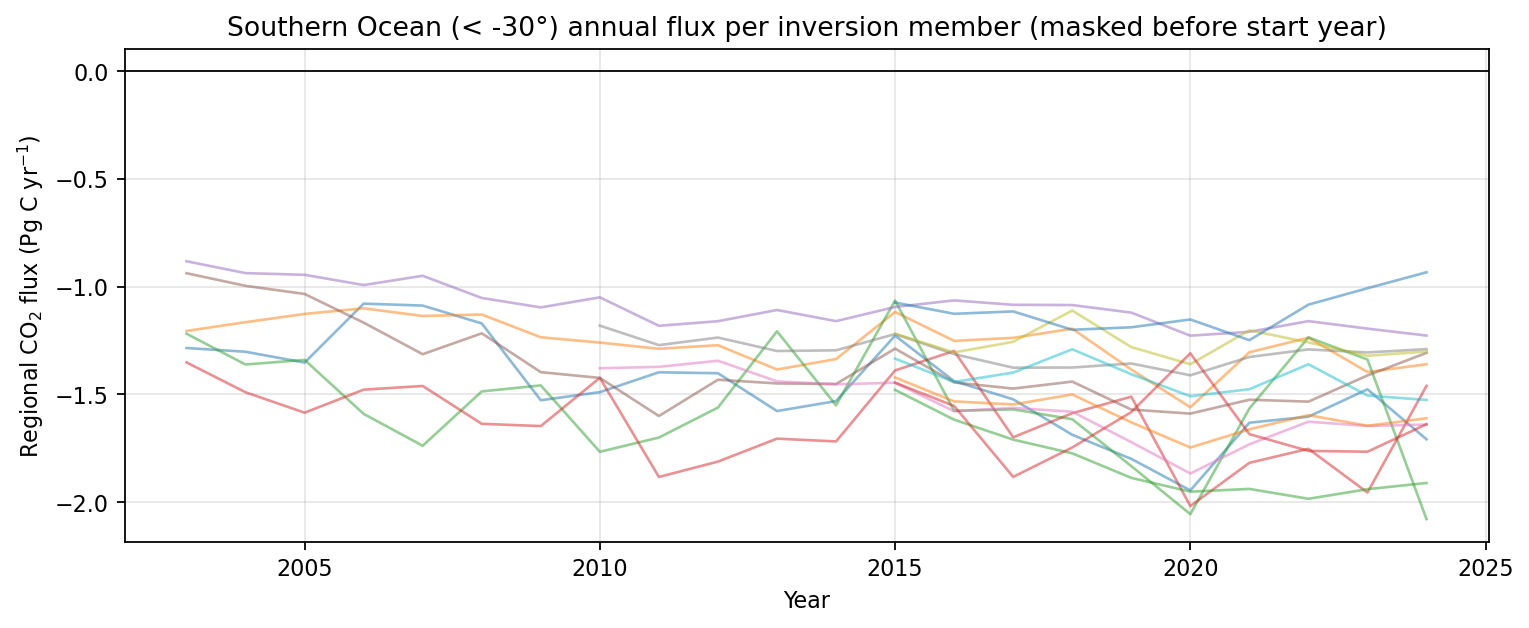

/tmp/ipykernel_2239865/3601138559.py:163: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc="best")


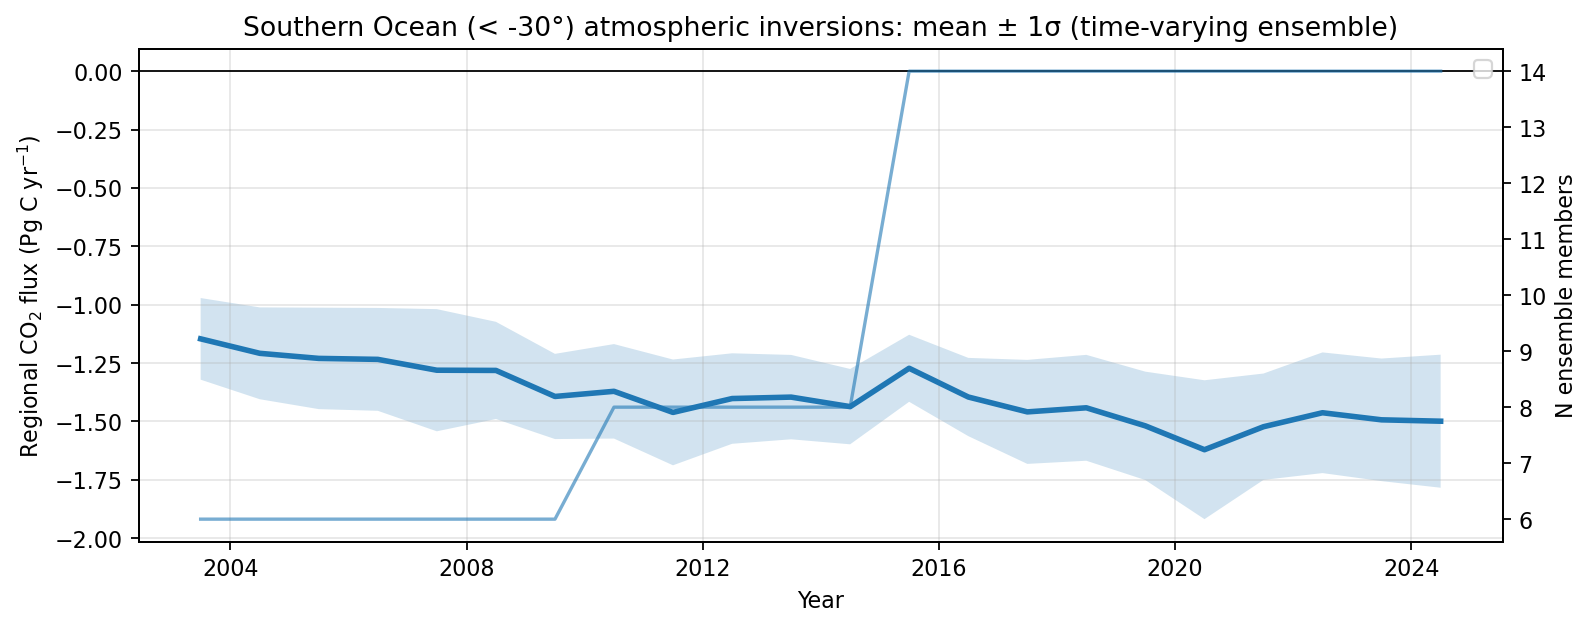


Ready for plotting:
inv_years shape: (22,)
inv_mean shape : (22,)
inv_std shape  : (22,)


In [7]:
# ============================================================
# GCB2025 Atmospheric inversions: Southern Ocean (< -30°S)
# Annual regional flux in PgC/yr, with a time-varying ensemble:
# each inversion member is included only from its first "active"
# year onward (detected from non-zero regional annual flux).
#
# Output sign convention: whatever the file provides.
# (For "uptake positive", flip sign at the end.)
# NO river adjustment applied to atmospheric inversions.
# ============================================================

import xarray as xr
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ----------------------------
# 1) Load dataset
# ----------------------------
inv_file = (
    "/remote/unity/bgc-output/DELAIGUE/SOCAT-FLOATS-OSSE/data/GCB/Atmosphere/"
    "GCP2025_inversions_1x1_version1_0_20251031.nc"
)

ds = xr.open_dataset(inv_file, engine="h5netcdf")

# ----------------------------
# 2) Define region mask: lat < -30
# ----------------------------
mask_south = ds["latitude"] < -30

# ----------------------------
# 3) Convert monthly flux rate -> monthly PgC
#    f is [PgC m-2 yr-1] at monthly resolution
#    monthly PgC = f * area * (days_in_month / 365.25)
# ----------------------------
f = ds["ocean_flux_NOT_adjusted"]                  # (ensemble_member, time, lat, lon)
A = ds["cell_area"]                               # (lat, lon)
days = ds["time"].dt.days_in_month                # (time,)

f_month_PgC = f * A * (days / 365.25)

# ----------------------------
# 4) Integrate over region -> PgC/month
# ----------------------------
south_month_PgC = f_month_PgC.where(mask_south).sum(
    dim=("latitude", "longitude"),
    skipna=True
)

# ----------------------------
# 5) Aggregate to annual PgC/yr
# ----------------------------
south_annual_PgCyr = south_month_PgC.groupby("time.year").sum("time")
south_annual_PgCyr = south_annual_PgCyr.rename({"year": "year"})  # explicit

# ----------------------------
# 6) Decode inversion member names (optional but useful)
# ----------------------------
member_names = [
    "".join(ds["ensemble_member_name"].sel(ensemble_member=i).values)
    for i in ds["ensemble_member"].values
]
print("\nEnsemble members:")
for i, n in enumerate(member_names):
    print(f"{i:2d}  {n}")

# ----------------------------
# 7) Time-varying ensemble inclusion:
#    For each member, find first year when |annual flux| > eps.
#    Mask that member before that year, then compute mean/std.
# ----------------------------
eps = 0.05  # PgC/yr threshold to detect "active" (tune if needed)

member_ann = south_annual_PgCyr  # (ensemble_member, year)

active = np.abs(member_ann) > eps  # True where member-year is "active"

# idxmax gives first coordinate of max (True > False); but if all False,
# idxmax returns the first year, so we must guard against "never active".
any_active = active.any(dim="year")

start_year = active.where(active).idxmax(dim="year")
start_year = start_year.where(any_active)  # members never active -> NaN

# Mask values prior to each member's start year
member_masked = member_ann.where(member_ann["year"] >= start_year)

# Ensemble stats ignoring NaNs
ens_mean = member_masked.mean("ensemble_member", skipna=True)
ens_std  = member_masked.std("ensemble_member", skipna=True)

# Number of contributing members each year
n_members = member_masked.notnull().sum("ensemble_member")

# ----------------------------
# 8) Restrict to comparison period
# ----------------------------
year_min, year_max = 2003, 2024
ens_mean = ens_mean.sel(year=slice(year_min, year_max))
ens_std  = ens_std.sel(year=slice(year_min, year_max))
n_members = n_members.sel(year=slice(year_min, year_max))

member_masked_period = member_masked.sel(year=slice(year_min, year_max))

# ----------------------------
# 9) Diagnostics: print start years and contributing count
# ----------------------------
print("\nDetected start year per member (eps = %.3f PgC/yr):" % eps)
for i, (n, y) in enumerate(zip(member_names, start_year.values)):
    y_str = "None" if np.isnan(y) else str(int(y))
    print(f"{i:2d}  {n:25s}  start_year={y_str}")

print("\nMembers contributing by year (after masking):")
for y, nm in zip(n_members["year"].values, n_members.values):
    print(f"{int(y)}: {int(nm)}")

# ----------------------------
# 10) Plot: (a) per-member (masked) (b) ensemble mean +/- 1σ
# ----------------------------
time = pd.to_datetime(ens_mean["year"].values.astype(str) + "-07-01")

plt.figure(figsize=(11, 4), dpi=160)
for i in member_masked_period["ensemble_member"].values:
    plt.plot(
        member_masked_period["year"].values,
        member_masked_period.sel(ensemble_member=i).values,
        alpha=0.5,
        lw=1.2
    )
plt.axhline(0, color="k", lw=0.8)
plt.title("Southern Ocean (< -30°) annual flux per inversion member (masked before start year)")
plt.xlabel("Year")
plt.ylabel("Regional CO$_2$ flux (Pg C yr$^{-1}$)")
plt.grid(True, alpha=0.3)
plt.show()

plt.figure(figsize=(11, 4), dpi=160)
plt.plot(time, ens_mean.values, lw=2.5, label="Inversion ensemble mean")
plt.fill_between(
    time,
    (ens_mean - ens_std).values,
    (ens_mean + ens_std).values,
    alpha=0.2,
    label=r"$\pm 1\sigma$"
)
plt.axhline(0, color="k", lw=0.8)
plt.title("Southern Ocean (< -30°) atmospheric inversions: mean ± 1σ (time-varying ensemble)")
plt.xlabel("Year")
plt.ylabel("Regional CO$_2$ flux (Pg C yr$^{-1}$)")
plt.grid(True, alpha=0.3)

# Optional: show number of contributing members on a secondary axis
ax = plt.gca()
ax2 = ax.twinx()
ax2.plot(time, n_members.values, lw=1.5, alpha=0.6)
ax2.set_ylabel("N ensemble members")

plt.legend(loc="best")
plt.show()

# ----------------------------
# 11) Final outputs for main figure
# ----------------------------
# ens_mean: (year,) annual PgC/yr
# ens_std : (year,) annual PgC/yr
# n_members: (year,) number of active members
#
# Convert to arrays if needed:
inv_years = ens_mean["year"].values
inv_mean = ens_mean.values
inv_std  = ens_std.values

print("\nReady for plotting:")
print("inv_years shape:", inv_years.shape)
print("inv_mean shape :", inv_mean.shape)
print("inv_std shape  :", inv_std.shape)


## PLOT

# Figure 5

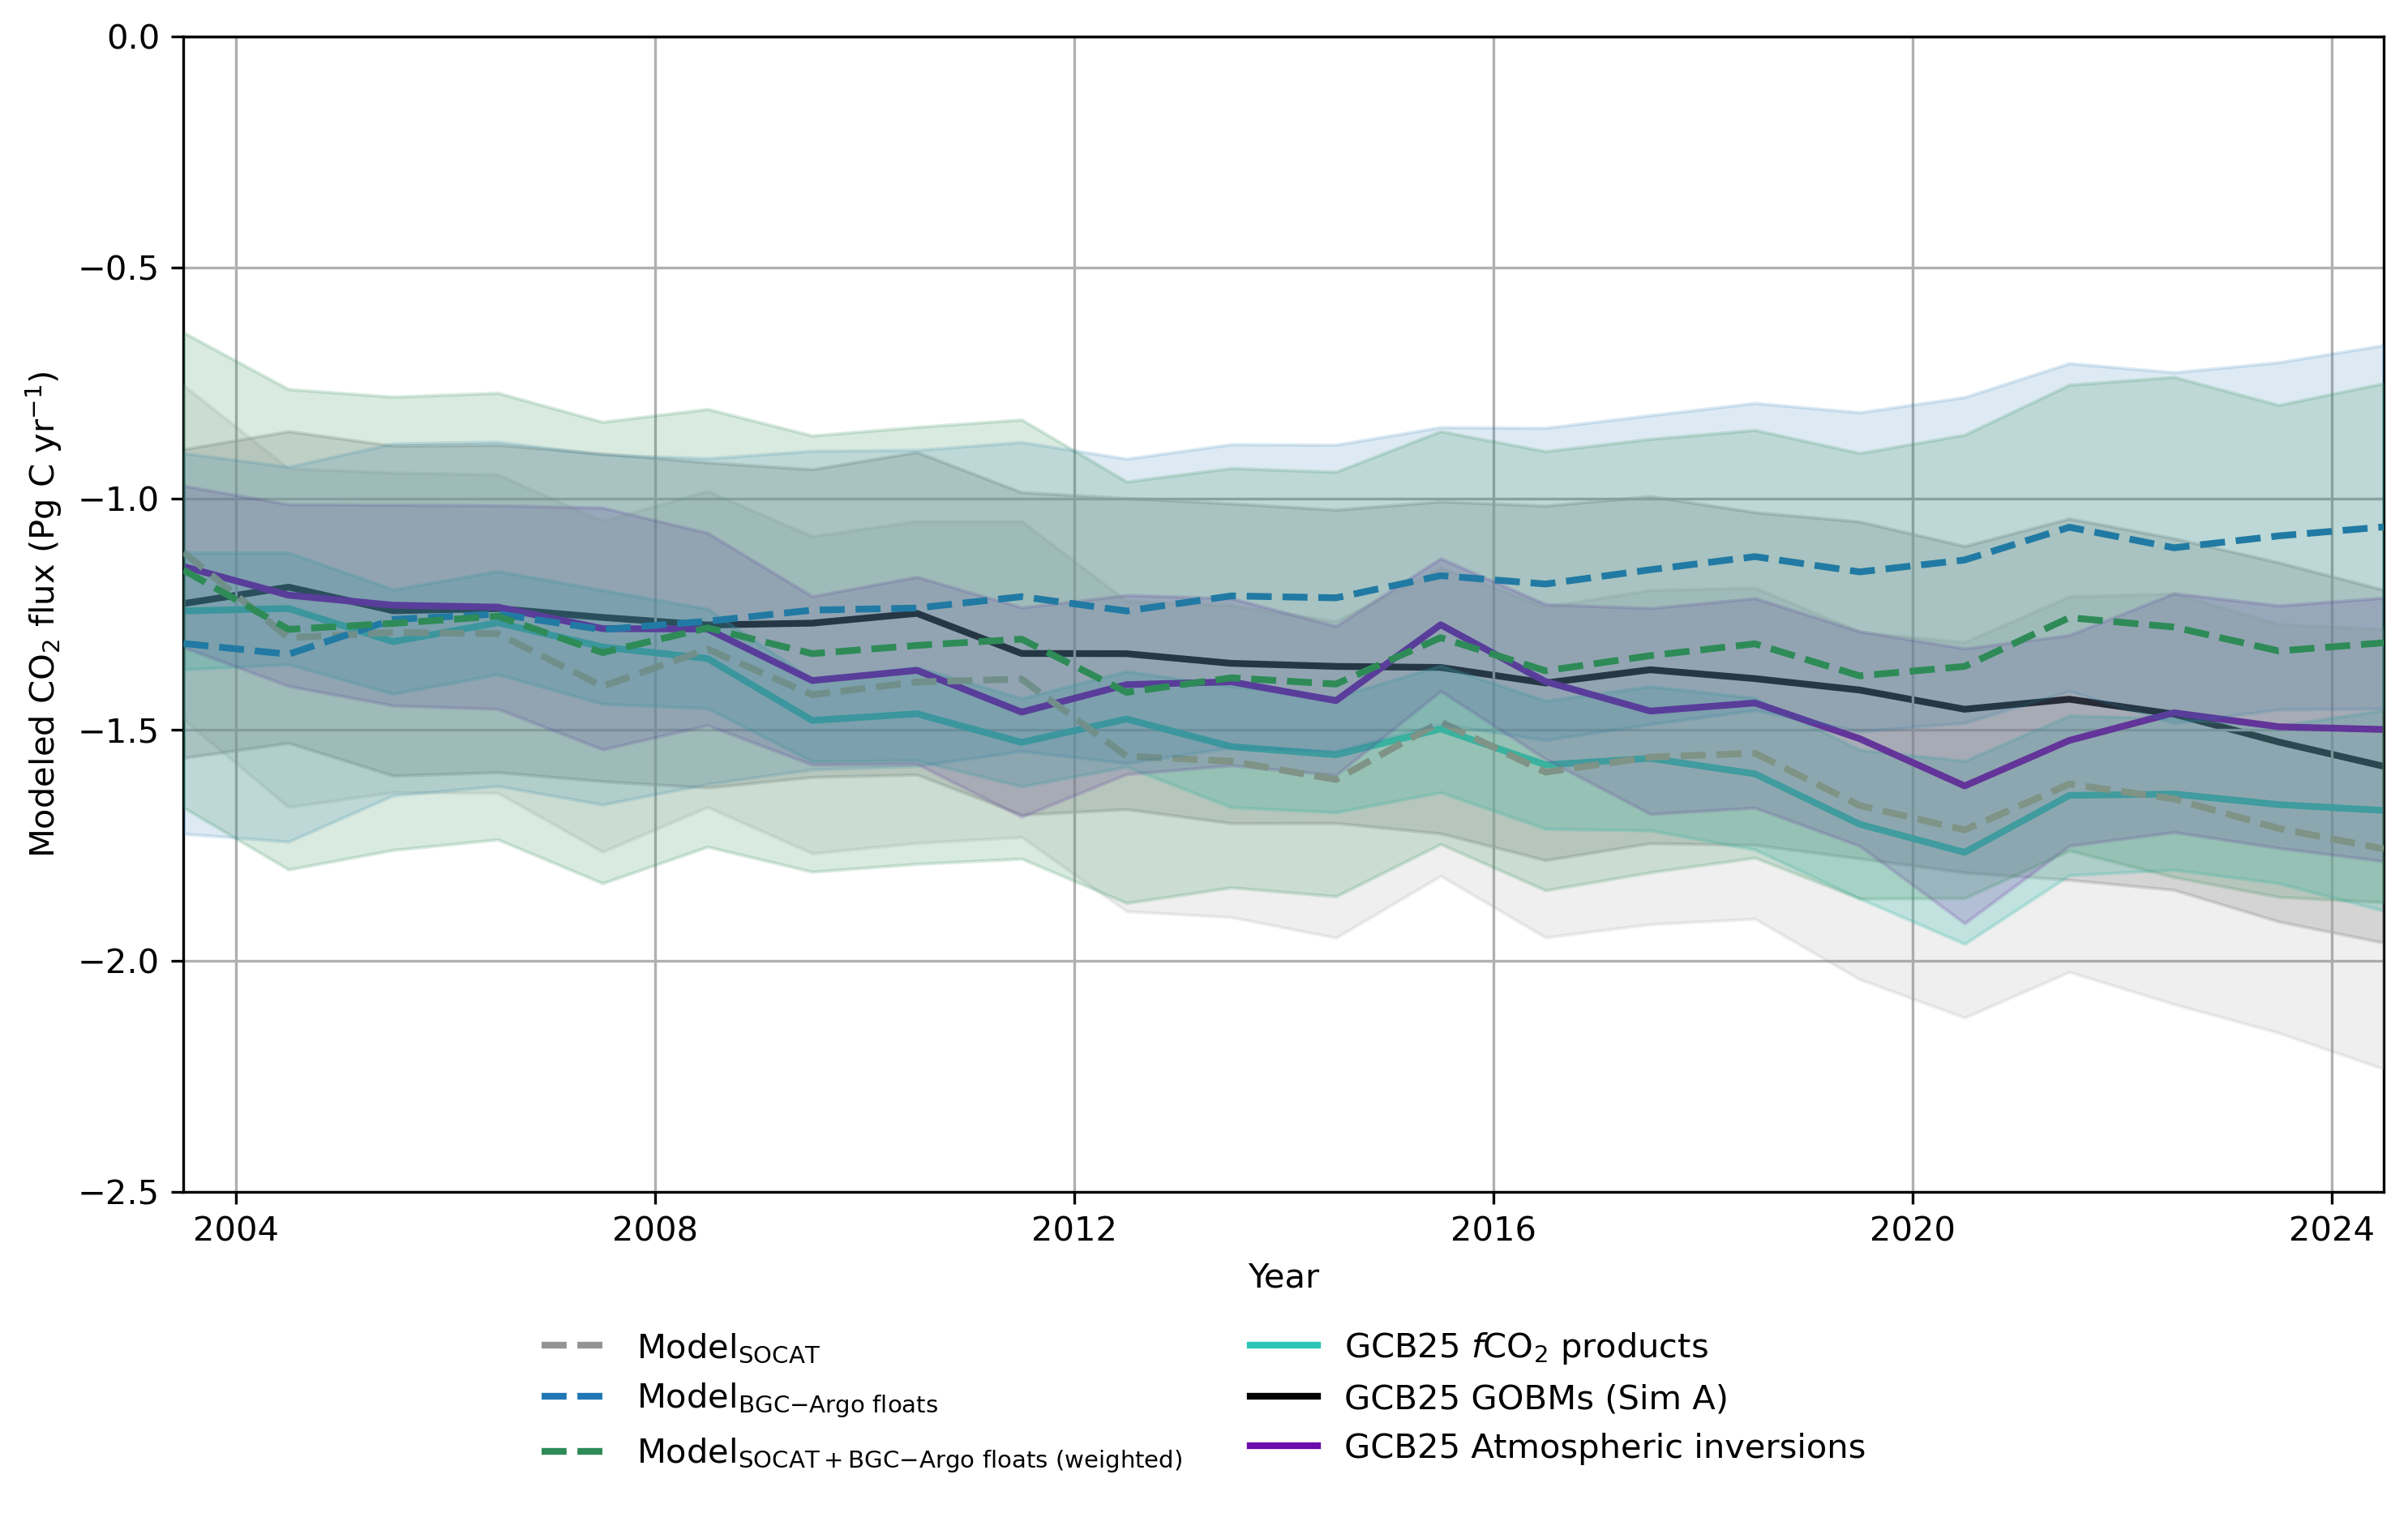

In [8]:
# ============================================================
# Figure X. Model comparison with GCB25 products, GOBMs, and inversions
# Assumes already available:
#   - ens_mean, ens_std
#   - fco2_ds
#   - gobm_ds
#   - yearly_flux_summary
# ============================================================

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

YEAR_MIN, YEAR_MAX = 2003, 2024
FIG_PATH = (
    "/remote/unity/bgc-output/DELAIGUE/SOCAT-FLOATS-OSSE/figs/"
    "Fig5.png"
)
YLIM = (-2.5, 0.0)


def year_to_datetime(year_values):
    return pd.to_datetime(pd.Index(year_values).astype(str) + "-07-01")


def plot_with_band(ax, x, y, sigma, *, label, color, linestyle="-", lw=2, alpha=0.15, zorder=1):
    line, = ax.plot(
        x,
        y,
        color=color,
        linestyle=linestyle,
        lw=lw,
        zorder=zorder,
        label=label,
    )
    ax.fill_between(
        x,
        y - sigma,
        y + sigma,
        color=color,
        alpha=alpha,
        zorder=zorder,
    )
    return line


# ------------------------------------------------------------
# Prepare datasets
# ------------------------------------------------------------

plot_df = yearly_flux_summary.loc[
    yearly_flux_summary["year"].between(YEAR_MIN, YEAR_MAX)
].copy()
plot_df["time"] = year_to_datetime(plot_df["year"])

ens_mean_plot = ens_mean.sel(year=slice(YEAR_MIN, YEAR_MAX))
ens_std_plot = ens_std.sel(year=slice(YEAR_MIN, YEAR_MAX))

time_inv = year_to_datetime(ens_mean_plot["year"].values)
inv_mean = ens_mean_plot.values
inv_std = ens_std_plot.values

time_gcb = year_to_datetime(fco2_ds["year"].values)
fco2_mean = fco2_ds["fgco2_products"].mean("product").values
fco2_std = fco2_ds["fgco2_products"].std("product").values

time_gobm = year_to_datetime(gobm_ds["year"].values)
gobm_mean = gobm_ds["gobm_mean"].values
gobm_std = gobm_ds["gobm_std"].values

# ------------------------------------------------------------
# Series configuration
# ------------------------------------------------------------

MODEL_SERIES = [
    {
        "x": plot_df["time"],
        "y": plot_df["SOCAT_predictions"].to_numpy(),
        "sigma": plot_df["SOCAT_predictions_sigma_PgC_yr"].to_numpy(),
        "label": r"Model$_{\mathrm{SOCAT}}$",
        "color": "#929591",
        "linestyle": "--",
        "alpha": 0.15,
        "zorder": 3,
    },
    {
        "x": plot_df["time"],
        "y": plot_df["floats_predictions"].to_numpy(),
        "sigma": plot_df["floats_predictions_sigma_PgC_yr"].to_numpy(),
        "label": r"Model$_{\mathrm{BGC{-}Argo\ floats}}$",
        "color": "tab:blue",
        "linestyle": "--",
        "alpha": 0.15,
        "zorder": 4,
    },
    {
        "x": plot_df["time"],
        "y": plot_df["combined_predictions_weighted"].to_numpy(),
        "sigma": plot_df["combined_predictions_weighted_sigma_PgC_yr"].to_numpy(),
        "label": r"Model$_{\mathrm{SOCAT+BGC{-}Argo\ floats\ (weighted)}}$",
        "color": "#2E8B57",
        "linestyle": "--",
        "alpha": 0.18,
        "zorder": 5,
    },
    {
        "x": time_gcb,
        "y": fco2_mean,
        "sigma": fco2_std,
        "label": r"GCB25 $f\mathrm{CO}_2$ products",
        "color": "#2EC4B6",
        "linestyle": "-",
        "alpha": 0.25,
        "zorder": 2,
    },
    {
        "x": time_gobm,
        "y": gobm_mean,
        "sigma": gobm_std,
        "label": "GCB25 GOBMs (Sim A)",
        "color": "black",
        "linestyle": "-",
        "alpha": 0.12,
        "zorder": 1,
    },
    {
        "x": time_inv,
        "y": inv_mean,
        "sigma": inv_std,
        "label": "GCB25 Atmospheric inversions",
        "color": "#6A0DAD",
        "linestyle": "-",
        "alpha": 0.18,
        "zorder": 2,
    },
]

# ------------------------------------------------------------
# Plot
# ------------------------------------------------------------

fig, ax = plt.subplots(figsize=(10, 6), dpi=300)

for cfg in MODEL_SERIES:
    plot_with_band(
        ax,
        cfg["x"],
        cfg["y"],
        cfg["sigma"],
        label=cfg["label"],
        color=cfg["color"],
        linestyle=cfg["linestyle"],
        alpha=cfg["alpha"],
        zorder=cfg["zorder"],
    )

ax.set_xlabel("Year")
ax.set_ylabel("Modeled CO$_2$ flux (Pg C yr$^{-1}$)")
ax.grid(True)
ax.axhline(0, color="k", lw=0.8)

ax.set_xlim(time_gobm.min(), time_gobm.max())
ax.set_ylim(*YLIM)

handles, labels = ax.get_legend_handles_labels()
fig.legend(
    handles,
    labels,
    loc="lower center",
    ncol=2,
    frameon=False,
    bbox_to_anchor=(0.5, -0.04),
)

fig.tight_layout(rect=[0, 0.08, 1, 1])
fig.savefig(FIG_PATH, dpi=300, bbox_inches="tight")
plt.show()

## Figure 6 (and old Table 2)


=== Table S2. Significance of multi-year mean Southern Ocean CO2 flux (2003–2024, south of 30°S) ===
Reported as mean ± σ_mean, with 95% CI from Monte Carlo propagation of annual uncertainties.

OBS$_{\mathrm{SOCAT}}$
  mean ± σ_mean = -1.43 ± 0.05 Pg C yr⁻¹
  95% CI        = -1.53 to -1.33 Pg C yr⁻¹
  P(mean < 0)   = 1.0000
  Significant sink? YES

Model$_{\mathrm{SOCAT}}$
  mean ± σ_mean = -1.50 ± 0.08 Pg C yr⁻¹
  95% CI        = -1.65 to -1.34 Pg C yr⁻¹
  P(mean < 0)   = 1.0000
  Significant sink? YES

OBS$_{\mathrm{BGC{-}Argo\ floats}}$
  mean ± σ_mean = -1.28 ± 0.32 Pg C yr⁻¹
  95% CI        = -1.91 to -0.64 Pg C yr⁻¹
  P(mean < 0)   = 1.0000
  Significant sink? YES

Model$_{\mathrm{BGC{-}Argo\ floats}}$
  mean ± σ_mean = -1.20 ± 0.08 Pg C yr⁻¹
  95% CI        = -1.34 to -1.05 Pg C yr⁻¹
  P(mean < 0)   = 1.0000
  Significant sink? YES

OBS$_{\mathrm{SOCAT+BGC{-}Argo\ floats}}$
  mean ± σ_mean = -1.36 ± 0.17 Pg C yr⁻¹
  95% CI        = -1.70 to -1.03 Pg C yr⁻¹
  P(mean < 0)   = 1.

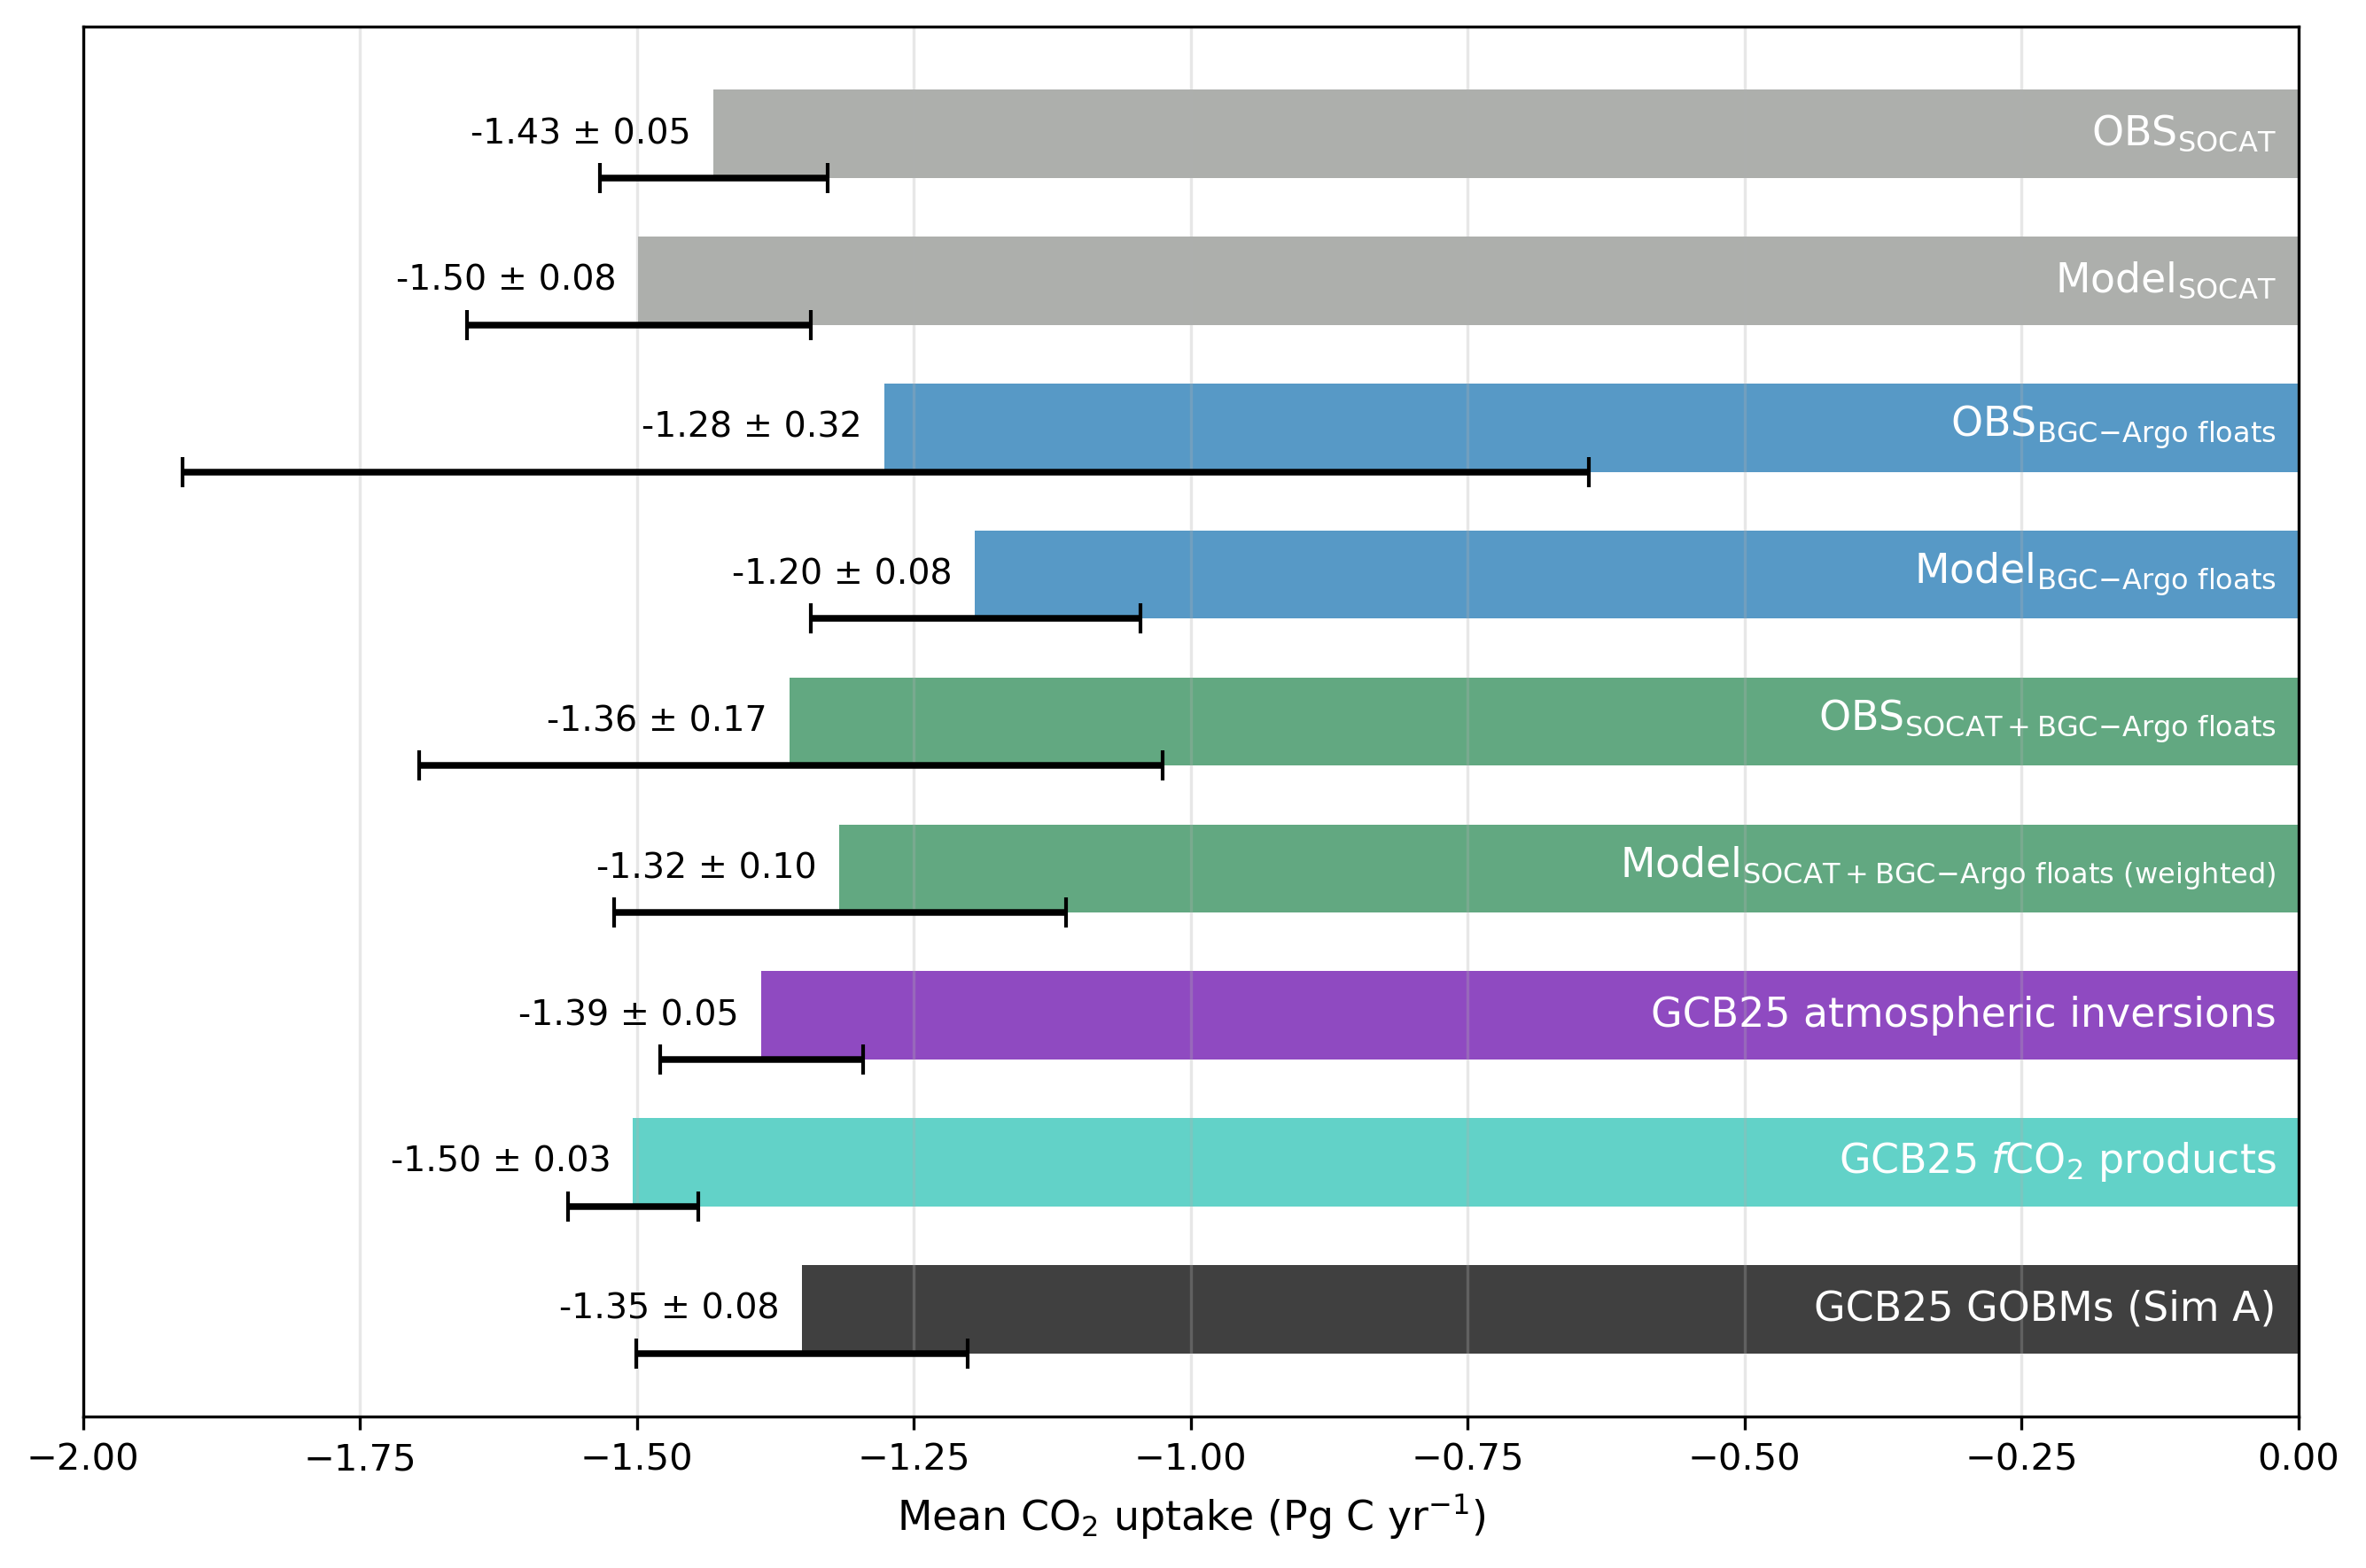


=== Multi-year mean Southern Ocean CO₂ uptake (2003–2024) ===
Reported as: mean ± σ_mean   (95% CI of multi-year mean)

OBS$_{\mathrm{SOCAT}}$
  mean =  -1.43 Pg C yr⁻¹
  σ_mean =  0.05
  95% CI = [-1.53, -1.33]
  P(mean < 0) = 1.0000

Model$_{\mathrm{SOCAT}}$
  mean =  -1.50 Pg C yr⁻¹
  σ_mean =  0.08
  95% CI = [-1.65, -1.34]
  P(mean < 0) = 1.0000

OBS$_{\mathrm{BGC{-}Argo\ floats}}$
  mean =  -1.28 Pg C yr⁻¹
  σ_mean =  0.32
  95% CI = [-1.91, -0.64]
  P(mean < 0) = 1.0000

Model$_{\mathrm{BGC{-}Argo\ floats}}$
  mean =  -1.20 Pg C yr⁻¹
  σ_mean =  0.08
  95% CI = [-1.34, -1.05]
  P(mean < 0) = 1.0000

OBS$_{\mathrm{SOCAT+BGC{-}Argo\ floats}}$
  mean =  -1.36 Pg C yr⁻¹
  σ_mean =  0.17
  95% CI = [-1.70, -1.03]
  P(mean < 0) = 1.0000

Model$_{\mathrm{SOCAT+BGC{-}Argo\ floats\ (weighted)}}$
  mean =  -1.32 Pg C yr⁻¹
  σ_mean =  0.10
  95% CI = [-1.52, -1.11]
  P(mean < 0) = 1.0000

GCB25 atmospheric inversions
  mean =  -1.39 Pg C yr⁻¹
  σ_mean =  0.05
  95% CI = [-1.48, -1.30]
  P

In [10]:
# ============================================================
# SUMMARY BAR PLOT (OBS + MODELS + GCB)
# mean bars + 95% CI errorbars at bottom
# text = mean ± σ_mean
#
# + PRINT TABLE S2 (mean, sigma_mean, CI95, P(mean<0))
# ============================================================

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

YEAR_MIN, YEAR_MAX = 2003, 2024
N_MC = 200000
SEED = 42

# ============================================================
# Monte Carlo helper
# ============================================================

def mc_stats(Fy, sy, N=200000, seed=42):
    """
    Returns:
      mean_est   : multi-year mean of annual means
      sigma_mean : std of MC distribution of the multi-year mean
      ci95       : (2.5%, 97.5%) of MC distribution of the multi-year mean
      p_neg      : P(mean < 0) from MC draws (useful for Table S2)
    """
    Fy = np.asarray(Fy, dtype=float)
    sy = np.asarray(sy, dtype=float)

    m = np.isfinite(Fy) & np.isfinite(sy)
    Fy, sy = Fy[m], sy[m]
    if Fy.size == 0:
        return np.nan, np.nan, (np.nan, np.nan), np.nan

    rng = np.random.default_rng(seed)
    draws = rng.normal(loc=Fy, scale=sy, size=(N, Fy.size))
    means = draws.mean(axis=1)

    mean_est = Fy.mean()
    sigma_mean = means.std(ddof=0)
    ci95 = np.quantile(means, [0.025, 0.975])
    p_neg = (means < 0).mean()

    return mean_est, sigma_mean, (ci95[0], ci95[1]), p_neg


# ============================================================
# Basic checks
# ============================================================

required_yearly_cols = [
    "year",
    "SOCAT",
    "SOCAT_sigma_PgC_yr",
    "SOCAT_predictions",
    "SOCAT_predictions_sigma_PgC_yr",
    "floats",
    "floats_sigma_PgC_yr",
    "floats_predictions",
    "floats_predictions_sigma_PgC_yr",
    "combined",
    "combined_sigma_PgC_yr",
    "combined_predictions_weighted",
    "combined_predictions_weighted_sigma_PgC_yr",
]

missing_cols = [c for c in required_yearly_cols if c not in yearly_flux_summary.columns]
if missing_cols:
    raise KeyError(
        "yearly_flux_summary is missing required columns: "
        + ", ".join(missing_cols)
    )

for obj_name in ["fco2_ds", "gobm_ds", "ens_mean", "ens_std"]:
    if obj_name not in globals():
        raise NameError(f"Required object '{obj_name}' is not defined.")


# ============================================================
# Subset to 2003–2024
# ============================================================

df = yearly_flux_summary.copy()
df = df[(df["year"] >= YEAR_MIN) & (df["year"] <= YEAR_MAX)].copy()

fco2_plot = fco2_ds.sel(year=slice(YEAR_MIN, YEAR_MAX))
gobm_plot = gobm_ds.sel(year=slice(YEAR_MIN, YEAR_MAX))

mask_inv = (ens_mean["year"] >= YEAR_MIN) & (ens_mean["year"] <= YEAR_MAX)
inv_mean = ens_mean.values[mask_inv]
inv_std = ens_std.values[mask_inv]


# ============================================================
# BUILD ROWS IN NEW ORDER
# Each row: (label, mean, sigma_mean, (ci_low, ci_high), p_neg, color)
# ============================================================

rows = []

# ---- SOCAT ----
m, s, ci, pneg = mc_stats(
    df["SOCAT"].values,
    df["SOCAT_sigma_PgC_yr"].values,
    N=N_MC,
    seed=SEED,
)
rows.append((r"OBS$_{\mathrm{SOCAT}}$", m, s, ci, pneg, "#929591"))

m, s, ci, pneg = mc_stats(
    df["SOCAT_predictions"].values,
    df["SOCAT_predictions_sigma_PgC_yr"].values,
    N=N_MC,
    seed=SEED,
)
rows.append((r"Model$_{\mathrm{SOCAT}}$", m, s, ci, pneg, "#929591"))

# ---- FLOATS ----
m, s, ci, pneg = mc_stats(
    df["floats"].values,
    df["floats_sigma_PgC_yr"].values,
    N=N_MC,
    seed=SEED,
)
rows.append((r"OBS$_{\mathrm{BGC{-}Argo\ floats}}$", m, s, ci, pneg, "tab:blue"))

m, s, ci, pneg = mc_stats(
    df["floats_predictions"].values,
    df["floats_predictions_sigma_PgC_yr"].values,
    N=N_MC,
    seed=SEED,
)
rows.append((r"Model$_{\mathrm{BGC{-}Argo\ floats}}$", m, s, ci, pneg, "tab:blue"))

# ---- COMBINED ----
m, s, ci, pneg = mc_stats(
    df["combined"].values,
    df["combined_sigma_PgC_yr"].values,
    N=N_MC,
    seed=SEED,
)
rows.append((r"OBS$_{\mathrm{SOCAT+BGC{-}Argo\ floats}}$", m, s, ci, pneg, "#2E8B57"))

m, s, ci, pneg = mc_stats(
    df["combined_predictions_weighted"].values,
    df["combined_predictions_weighted_sigma_PgC_yr"].values,
    N=N_MC,
    seed=SEED,
)
rows.append((
    r"Model$_{\mathrm{SOCAT+BGC{-}Argo\ floats\ (weighted)}}$",
    m, s, ci, pneg, "#2E8B57"
))

# ---- GCB ----
m, s, ci, pneg = mc_stats(inv_mean, inv_std, N=N_MC, seed=SEED)
rows.append(("GCB25 atmospheric inversions", m, s, ci, pneg, "#6A0DAD"))

Fy = fco2_plot["fgco2_products"].mean("product").values
sy = fco2_plot["fgco2_products"].std("product").values
m, s, ci, pneg = mc_stats(Fy, sy, N=N_MC, seed=SEED)
rows.append(("GCB25 $f\\mathrm{CO}_2$ products", m, s, ci, pneg, "#2EC4B6"))

m, s, ci, pneg = mc_stats(
    gobm_plot["gobm_mean"].values,
    gobm_plot["gobm_std"].values,
    N=N_MC,
    seed=SEED,
)
rows.append(("GCB25 GOBMs (Sim A)", m, s, ci, pneg, "k"))


# ============================================================
# PRINT TABLE S2 CONTENT (publication-ready)
# ============================================================

print("\n=== Table S2. Significance of multi-year mean Southern Ocean CO2 flux (2003–2024, south of 30°S) ===")
print("Reported as mean ± σ_mean, with 95% CI from Monte Carlo propagation of annual uncertainties.\n")

table_rows = []
for label, mean_est, sigma_mean, (ci_l, ci_u), pneg, color in rows:
    sig = "YES" if (ci_l < 0) and (ci_u < 0) else "NO"
    table_rows.append({
        "Dataset": label,
        "Mean (Pg C yr-1)": mean_est,
        "σ_mean (Pg C yr-1)": sigma_mean,
        "95% CI low (Pg C yr-1)": ci_l,
        "95% CI high (Pg C yr-1)": ci_u,
        "P(mean < 0)": pneg,
        "Significant sink?": sig,
    })

    print(f"{label}")
    print(f"  mean ± σ_mean = {mean_est:.2f} ± {sigma_mean:.2f} Pg C yr⁻¹")
    print(f"  95% CI        = {ci_l:.2f} to {ci_u:.2f} Pg C yr⁻¹")
    print(f"  P(mean < 0)   = {pneg:.4f}")
    print(f"  Significant sink? {sig}\n")

df_S2 = pd.DataFrame(table_rows)


# ============================================================
# ARRAYS FOR PLOTTING (mirror order)
# ============================================================

labels_plot = [r[0] for r in rows][::-1]
means_plot = np.array([r[1] for r in rows], dtype=float)[::-1]
sigmas_plot = np.array([r[2] for r in rows], dtype=float)[::-1]
ci_low = np.array([r[3][0] for r in rows], dtype=float)[::-1]
ci_high = np.array([r[3][1] for r in rows], dtype=float)[::-1]
colors = [r[5] for r in rows][::-1]

err_left = means_plot - ci_low
err_right = ci_high - means_plot


# ============================================================
# PLOT
# ============================================================

fig, ax = plt.subplots(figsize=(9, 6.0), dpi=300)
ypos = np.arange(len(labels_plot))
bar_height = 0.6

ax.barh(ypos, means_plot, color=colors, alpha=0.75, height=bar_height)

# 95% CI bottom bars
for i, (mval, el, er) in enumerate(zip(means_plot, err_left, err_right)):
    ax.errorbar(
        mval,
        i - bar_height / 2,
        xerr=np.array([[el], [er]]),
        fmt="none",
        ecolor="black",
        elinewidth=1.8,
        capsize=4,
        zorder=5,
    )

# Labels
for i, (label, mval, smean) in enumerate(zip(labels_plot, means_plot, sigmas_plot)):
    ax.text(
        -0.02,
        i,
        label,
        va="center",
        ha="right",
        color="white",
        fontsize=11,
    )
    ax.text(
        mval - 0.02,
        i,
        f"{mval:.2f} ± {smean:.2f}",
        va="center",
        ha="right",
        fontsize=9.5,
        color="black",
    )

# Formatting
ax.set_yticks([])
ax.set_xlabel("Mean CO$_2$ uptake (Pg C yr$^{-1}$)", fontsize=11)
ax.set_xlim(-2.0, 0)
ax.grid(axis="x", alpha=0.3)

plt.tight_layout()

fig.savefig(
    "/remote/unity/bgc-output/DELAIGUE/SOCAT-FLOATS-OSSE/figs/Fig6.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()


# ============================================================
# PRINT NUMERICAL SUMMARY (same values used in bars)
# ============================================================

print("\n=== Multi-year mean Southern Ocean CO₂ uptake (2003–2024) ===")
print("Reported as: mean ± σ_mean   (95% CI of multi-year mean)\n")

for label, mean_est, sigma_mean, (ci_l, ci_u), pneg, color in rows:
    print(f"{label}")
    print(f"  mean = {mean_est:6.2f} Pg C yr⁻¹")
    print(f"  σ_mean = {sigma_mean:5.2f}")
    print(f"  95% CI = [{ci_l:5.2f}, {ci_u:5.2f}]")
    print(f"  P(mean < 0) = {pneg:.4f}\n")

# Table 3

In [11]:
# ============================================================
# Linear trends in Southern Ocean CO2 uptake (2003–2024)
# MLP products, GCB products, GOBMs, and atmospheric inversions
# ============================================================

from scipy.stats import linregress
import numpy as np
import pandas as pd

YEAR_MIN, YEAR_MAX = 2003, 2024

# ------------------------------------------------------------
# Helpers
# ------------------------------------------------------------

def restrict_years_df(df, year_col="year", year_min=YEAR_MIN, year_max=YEAR_MAX):
    return df.loc[df[year_col].between(year_min, year_max)].copy()


def restrict_years_xr(ds, year_min=YEAR_MIN, year_max=YEAR_MAX):
    return ds.sel(year=slice(year_min, year_max))


def compute_trend(years, values, label, category):
    years = np.asarray(years)
    values = np.asarray(values)

    valid = np.isfinite(years) & np.isfinite(values)
    years = years[valid]
    values = values[valid]

    slope, intercept, r_value, p_value, stderr = linregress(years, values)

    return {
        "category": category,
        "label": label,
        "n_years": len(years),
        "slope_PgC_yr2": slope,
        "stderr_PgC_yr2": stderr,
        "p_value": p_value,
        "r_value": r_value,
        "intercept": intercept,
    }


def print_trend_report(trends_df, year_min=YEAR_MIN, year_max=YEAR_MAX):
    print(f"\n=== Linear Trends in Southern Ocean CO₂ Uptake ({year_min}–{year_max}) ===\n")

    for category in ["Observations", "Models", "GCB", "Atmospheric inversions"]:
        subset = trends_df.loc[trends_df["category"] == category]
        if subset.empty:
            continue

        print(f"{category}:")
        for _, row in subset.iterrows():
            print(
                f"  {row['label']:<32} "
                f"{row['slope_PgC_yr2']:.4f} ± {row['stderr_PgC_yr2']:.4f} "
                f"Pg C yr⁻² (p = {row['p_value']:.2e})"
            )
        print()

    print("--- Full table ---")
    print(trends_df.to_string(index=False))


# ------------------------------------------------------------
# Prepare datasets
# ------------------------------------------------------------

mlp_df = restrict_years_df(yearly_flux_summary, year_min=YEAR_MIN, year_max=YEAR_MAX)
years_mlp = mlp_df["year"].to_numpy()

fco2_plot = restrict_years_xr(fco2_ds, year_min=YEAR_MIN, year_max=YEAR_MAX)
gobm_plot = restrict_years_xr(gobm_ds, year_min=YEAR_MIN, year_max=YEAR_MAX)
inv_plot = restrict_years_xr(ens_mean, year_min=YEAR_MIN, year_max=YEAR_MAX)

# ------------------------------------------------------------
# Define trend inputs
# ------------------------------------------------------------

trend_specs = [
    {
        "category": "Observations",
        "label": "SOCAT observed",
        "years": years_mlp,
        "values": mlp_df["SOCAT"].to_numpy(),
    },
    {
        "category": "Observations",
        "label": "FLOATS observed",
        "years": years_mlp,
        "values": mlp_df["floats"].to_numpy(),
    },
    {
        "category": "Observations",
        "label": "SOCAT+BGC-Argo observed",
        "years": years_mlp,
        "values": mlp_df["combined"].to_numpy(),
    },
    {
        "category": "Models",
        "label": "SOCAT model",
        "years": years_mlp,
        "values": mlp_df["SOCAT_predictions"].to_numpy(),
    },
    {
        "category": "Models",
        "label": "FLOATS model",
        "years": years_mlp,
        "values": mlp_df["floats_predictions"].to_numpy(),
    },
    {
        "category": "Models",
        "label": "SOCAT+BGC-Argo model (weighted)",
        "years": years_mlp,
        "values": mlp_df["combined_predictions_weighted"].to_numpy(),
    },
    {
        "category": "GCB",
        "label": "GCB fCO₂ products",
        "years": fco2_plot["year"].values,
        "values": fco2_plot["fgco2_products"].mean("product").values,
    },
    {
        "category": "GCB",
        "label": "GCB GOBMs (Sim A)",
        "years": gobm_plot["year"].values,
        "values": gobm_plot["gobm_mean"].values,
    },
    {
        "category": "Atmospheric inversions",
        "label": "Atmospheric inversions",
        "years": inv_plot["year"].values,
        "values": inv_plot.values,
    },
]

# ------------------------------------------------------------
# Compute trends
# ------------------------------------------------------------

trends = pd.DataFrame(
    compute_trend(
        spec["years"],
        spec["values"],
        label=spec["label"],
        category=spec["category"],
    )
    for spec in trend_specs
)

# Optional: preserve a nice category order
category_order = {
    "Observations": 0,
    "Models": 1,
    "GCB": 2,
    "Atmospheric inversions": 3,
}
trends = (
    trends.assign(_order=trends["category"].map(category_order))
    .sort_values(["_order", "label"])
    .drop(columns="_order")
    .reset_index(drop=True)
)

# ------------------------------------------------------------
# Report
# ------------------------------------------------------------

print_trend_report(trends, year_min=YEAR_MIN, year_max=YEAR_MAX)


=== Linear Trends in Southern Ocean CO₂ Uptake (2003–2024) ===

Observations:
  FLOATS observed                  0.0302 ± 0.0118 Pg C yr⁻² (p = 1.84e-02)
  SOCAT observed                   -0.0369 ± 0.0049 Pg C yr⁻² (p = 2.56e-07)
  SOCAT+BGC-Argo observed          -0.0125 ± 0.0054 Pg C yr⁻² (p = 3.22e-02)

Models:
  FLOATS model                     0.0117 ± 0.0007 Pg C yr⁻² (p = 5.67e-13)
  SOCAT model                      -0.0244 ± 0.0020 Pg C yr⁻² (p = 1.22e-10)
  SOCAT+BGC-Argo model (weighted)  -0.0033 ± 0.0019 Pg C yr⁻² (p = 9.70e-02)

GCB:
  GCB GOBMs (Sim A)                -0.0152 ± 0.0009 Pg C yr⁻² (p = 3.47e-13)
  GCB fCO₂ products                -0.0226 ± 0.0019 Pg C yr⁻² (p = 9.73e-11)

Atmospheric inversions:
  Atmospheric inversions           -0.0161 ± 0.0021 Pg C yr⁻² (p = 2.91e-07)

--- Full table ---
              category                           label  n_years  slope_PgC_yr2  stderr_PgC_yr2      p_value   r_value  intercept
          Observations                 FL

In [12]:
from scipy.stats import linregress
import numpy as np

# ============================================================
# What this script reports
# ------------------------------------------------------------
# - We fit a linear trend of FLUX vs YEAR within each window.
# - Flux convention: negative = uptake.
# - We REPORT the flux trend dF/dt in units of Pg C yr^-1 decade^-1.
#   (This is just the fitted per-year slope expressed per decade.)
# - We DO NOT multiply by -1 anywhere (no "sink-growth" sign flip).
# - z-scores are ONLY computed for 2003–2018 and compare to Hauck et al.
#   Hauck reports sink-growth (+ = stronger sink), so we convert Hauck to
#   flux-trend convention by flipping the sign of the reference.
# ============================================================

# ==========================
# Helpers
# ==========================
def fit_trend(years, flux):
    """Return slope, stderr, p for flux = a*year + b. slope is per YEAR."""
    slope, _, _, p, stderr = linregress(years.astype(float), flux.astype(float))
    return slope, stderr, p

def summarize_window_flux_trend(label, years, flux, y0, y1, ref_val=None, ref_unc=None):
    """
    Fit trend over [y0, y1] and report:
      - trend_dec: dF/dt in Pg C yr^-1 decade^-1  (NEGATIVE => strengthening uptake)
      - trend_dec_se: SE of trend_dec
      - p: p-value of slope (same regardless of unit scaling)
      - deltaF: total change in flux across window (Pg C yr^-1), using fitted slope
      - z: optional z-score vs reference (only when ref provided)
    """
    m = (years >= y0) & (years <= y1)
    yrs = years[m]
    y   = flux[m]

    slope, stderr, p = fit_trend(yrs, y)  # slope per year: Pg C yr^-2

    # Express slope per decade (unit conversion; no sign flip)
    trend_dec    = slope * 10.0
    trend_dec_se = stderr * 10.0

    # Total change in flux across the window (Pg C yr^-1)
    deltaF = slope * (y1 - y0)

    out = {
        "label": label,
        "y0": y0, "y1": y1,
        "trend_dec": trend_dec,
        "trend_dec_se": trend_dec_se,
        "p": p,
        "deltaF": deltaF,
        "n": int(np.sum(m)),
        "ref_val": ref_val,
        "ref_unc": ref_unc,
        "z": None
    }

    if (ref_val is not None) and (ref_unc is not None):
        out["z"] = (trend_dec - ref_val) / np.sqrt(trend_dec_se**2 + ref_unc**2)

    return out

def fmt_sci(x):
    """Format p-values like 5.74 × 10⁻⁶ (ASCII-friendly)."""
    if x is None:
        return "NA"
    if x == 0:
        return "0"
    exp = int(np.floor(np.log10(abs(x))))
    mant = x / (10**exp)
    return f"{mant:.2f} × 10{exp:+d}".replace("+", "⁺").replace("-", "⁻")

def cell(trend, se, p, z):
    """Format as: +0.493 ± 0.070 (5.74 × 10⁻⁶; +5.04) ; z=NA if missing."""
    ztxt = f"{z:+.2f}" if z is not None else "NA"
    return f"{trend:+.3f} ± {se:.3f} ({fmt_sci(p)}; {ztxt})"

# ==========================
# Windows
# ==========================
windows = {
    "2003–2018 (Hauck et al., 2023a)": (2003, 2018),
    "2003–2012": (2003, 2012),
    "2015–2024": (2015, 2024),
}

# ==========================
# Hauck et al. (2023a) references
# Hauck reports SINK-GROWTH (positive = stronger sink) in Pg C yr^-1 decade^-1.
# We are reporting FLUX-TREND dF/dt (negative = stronger sink),
# so reference values must be SIGN-FLIPPED.
# ==========================
hauck_pco2_sinkgrowth, hauck_pco2_unc = 0.26, 0.06  # reported as sink-growth
hauck_gobm_sinkgrowth, hauck_gobm_unc = 0.11, 0.03  # reported as sink-growth

hauck_pco2_fluxtrend = -hauck_pco2_sinkgrowth  # convert to flux-trend convention
hauck_gobm_fluxtrend = -hauck_gobm_sinkgrowth  # convert to flux-trend convention

# ==========================
# Series getters (as in script)
# Assumes these exist: yearly_flux_summary, fco2_ds, gobm_ds
# ==========================
def df_series(df, y0, y1, col):
    m = (df["year"] >= y0) & (df["year"] <= y1)
    return df.loc[m, "year"].values, df.loc[m, col].values

def gcb_fco2_series(y0, y1):
    sub = fco2_ds.sel(year=slice(y0, y1))
    yrs = sub["year"].values
    y   = sub["fgco2_products"].mean("product").values
    return yrs, y

def gcb_gobm_series(y0, y1):
    sub = gobm_ds.sel(year=slice(y0, y1))
    yrs = sub["year"].values
    y   = sub["gobm_mean"].values
    return yrs, y

# ==========================
# Model columns
# ==========================
my_models = {
    "Model$_{\\mathrm{SOCATv2025}}$": "SOCAT_predictions",
    "Model$_{\\mathrm{BGC\\text{-}Argo\\ floats}}$": "floats_predictions",
    "Model$_{\\mathrm{SOCATv2025+BGC\\text{-}Argo\\ floats}}$ (weighted)": "combined_predictions_weighted",
}

# ==========================
# Build the table
# ==========================
table = {name: {} for name in my_models.keys()}

for win_name, (y0, y1) in windows.items():
    for label, col in my_models.items():
        yrs, y = df_series(yearly_flux_summary, y0, y1, col)

        # Only compute z-scores for 2003–2018 vs Hauck pCO2-products reference
        if y0 == 2003 and y1 == 2018:
            ref_val, ref_unc = hauck_pco2_fluxtrend, hauck_pco2_unc
        else:
            ref_val, ref_unc = None, None

        r = summarize_window_flux_trend(label, yrs, y, y0, y1, ref_val=ref_val, ref_unc=ref_unc)
        table[label][win_name] = cell(r["trend_dec"], r["trend_dec_se"], r["p"], r["z"])

# ==========================
# Print as a Word-friendly table (TSV-like)
# ==========================
cols = list(windows.keys())
print("Dataset\t" + "\t".join(cols))
for label in my_models.keys():
    print(label + "\t" + "\t".join(table[label][c] for c in cols))

# --------------------------
# Notes:
# - Negative values here mean flux becomes more negative -> uptake strengthens.
# - If we want to compare to Hauck in sink-growth units instead, don't sign-flip the reference.
# --------------------------

Dataset	2003–2018 (Hauck et al., 2023a)	2003–2012	2015–2024
Model$_{\mathrm{SOCATv2025}}$	-0.264 ± 0.035 (2.82 × 10⁻6; -0.05)	-0.330 ± 0.068 (1.23 × 10⁻3; NA)	-0.244 ± 0.052 (1.49 × 10⁻3; NA)
Model$_{\mathrm{BGC\text{-}Argo\ floats}}$	+0.111 ± 0.011 (8.77 × 10⁻8; +6.08)	+0.101 ± 0.025 (3.96 × 10⁻3; NA)	+0.129 ± 0.024 (7.08 × 10⁻4; NA)
Model$_{\mathrm{SOCATv2025+BGC\text{-}Argo\ floats}}$ (weighted)	-0.087 ± 0.028 (6.97 × 10⁻3; +2.61)	-0.179 ± 0.048 (5.50 × 10⁻3; NA)	+0.042 ± 0.045 (3.76 × 10⁻1; NA)


## Figure 7

In [13]:
# ============================================================
# SEASONAL MAPS (4 PANELS) — EXACT SAME FIGURE STYLE AS TEMPLATE
# ONLY DIFFERENCE: THE DATA PLOTTED = (SOCAT predictions − COMBINED weighted predictions)
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from matplotlib.colors import Normalize

# ============================================================
# 1) LOAD PREDICTIONS (SOCAT + COMBINED WEIGHTED)
# ============================================================

predictions_socat = pd.read_csv(
    "/remote/unity/bgc-output/DELAIGUE/SOCAT-FLOATS-OSSE/PREDICTION_MATRIX_v2/matrix_predictions/"
    "pco2_prediction_matrix_SOCAT_only_MCensemble.csv"
)

predictions_combined_weighted = pd.read_csv(
    "/remote/unity/bgc-output/DELAIGUE/SOCAT-FLOATS-OSSE/PREDICTION_MATRIX_v2/matrix_predictions/"
    "pco2_prediction_matrix_SOCAT_AND_FLOATS_weighted_MCensemble.csv"
)

for df in (predictions_socat, predictions_combined_weighted):
    df["month_center"] = pd.to_datetime(df["month_center"])
    df.drop(
        df[(df["month_center"].dt.year == 2023) &
           (df["month_center"].dt.month == 2)].index,
        inplace=True
    )

# ============================================================
# 2) ADD DJF/MAM/JJA/SON SEASON LABELS (TO MATCH TEMPLATE)
# ============================================================

def assign_season(month):
    if month in [12, 1, 2]:
        return "DJF"
    elif month in [3, 4, 5]:
        return "MAM"
    elif month in [6, 7, 8]:
        return "JJA"
    else:
        return "SON"

for df in (predictions_socat, predictions_combined_weighted):
    df["month"] = df["month_center"].dt.month
    df["season"] = df["month"].apply(assign_season)

# ============================================================
# 3) SEASONAL MEAN PER GRID CELL (AUTO-DETECT LAT/LON)
# ============================================================

def seasonal_mean_pred(df, pred_col="ensemble_pco2_pred"):
    """
    Seasonal mean prediction per season per grid cell.
    Auto-detects:
      - latitude/longitude
      - OR lat_center/lon_center
    Returns columns: season, latitude, longitude, pco2_pred
    """
    if {"latitude", "longitude"}.issubset(df.columns):
        lat_col, lon_col = "latitude", "longitude"
    elif {"lat_center", "lon_center"}.issubset(df.columns):
        lat_col, lon_col = "lat_center", "lon_center"
    else:
        raise KeyError("No valid latitude/longitude columns found in dataframe.")

    out = (
        df.groupby(["season", lat_col, lon_col])[pred_col]
          .mean()
          .reset_index()
          .rename(columns={lat_col: "latitude", lon_col: "longitude", pred_col: "pco2_pred"})
    )
    return out

seasonal_socat = seasonal_mean_pred(predictions_socat)
seasonal_cw    = seasonal_mean_pred(predictions_combined_weighted)

# ============================================================
# 4) BUILD THE DATA TO PLOT: SOCAT − COMBINED WEIGHTED
# (this is the ONLY difference vs  template: variable/colormapping)
# ============================================================

df_seasonal = seasonal_socat.merge(
    seasonal_cw,
    on=["season", "latitude", "longitude"],
    suffixes=("_socat", "_cw"),
    how="inner"
)

df_seasonal["delta_pco2"] = df_seasonal["pco2_pred_socat"] - df_seasonal["pco2_pred_cw"]




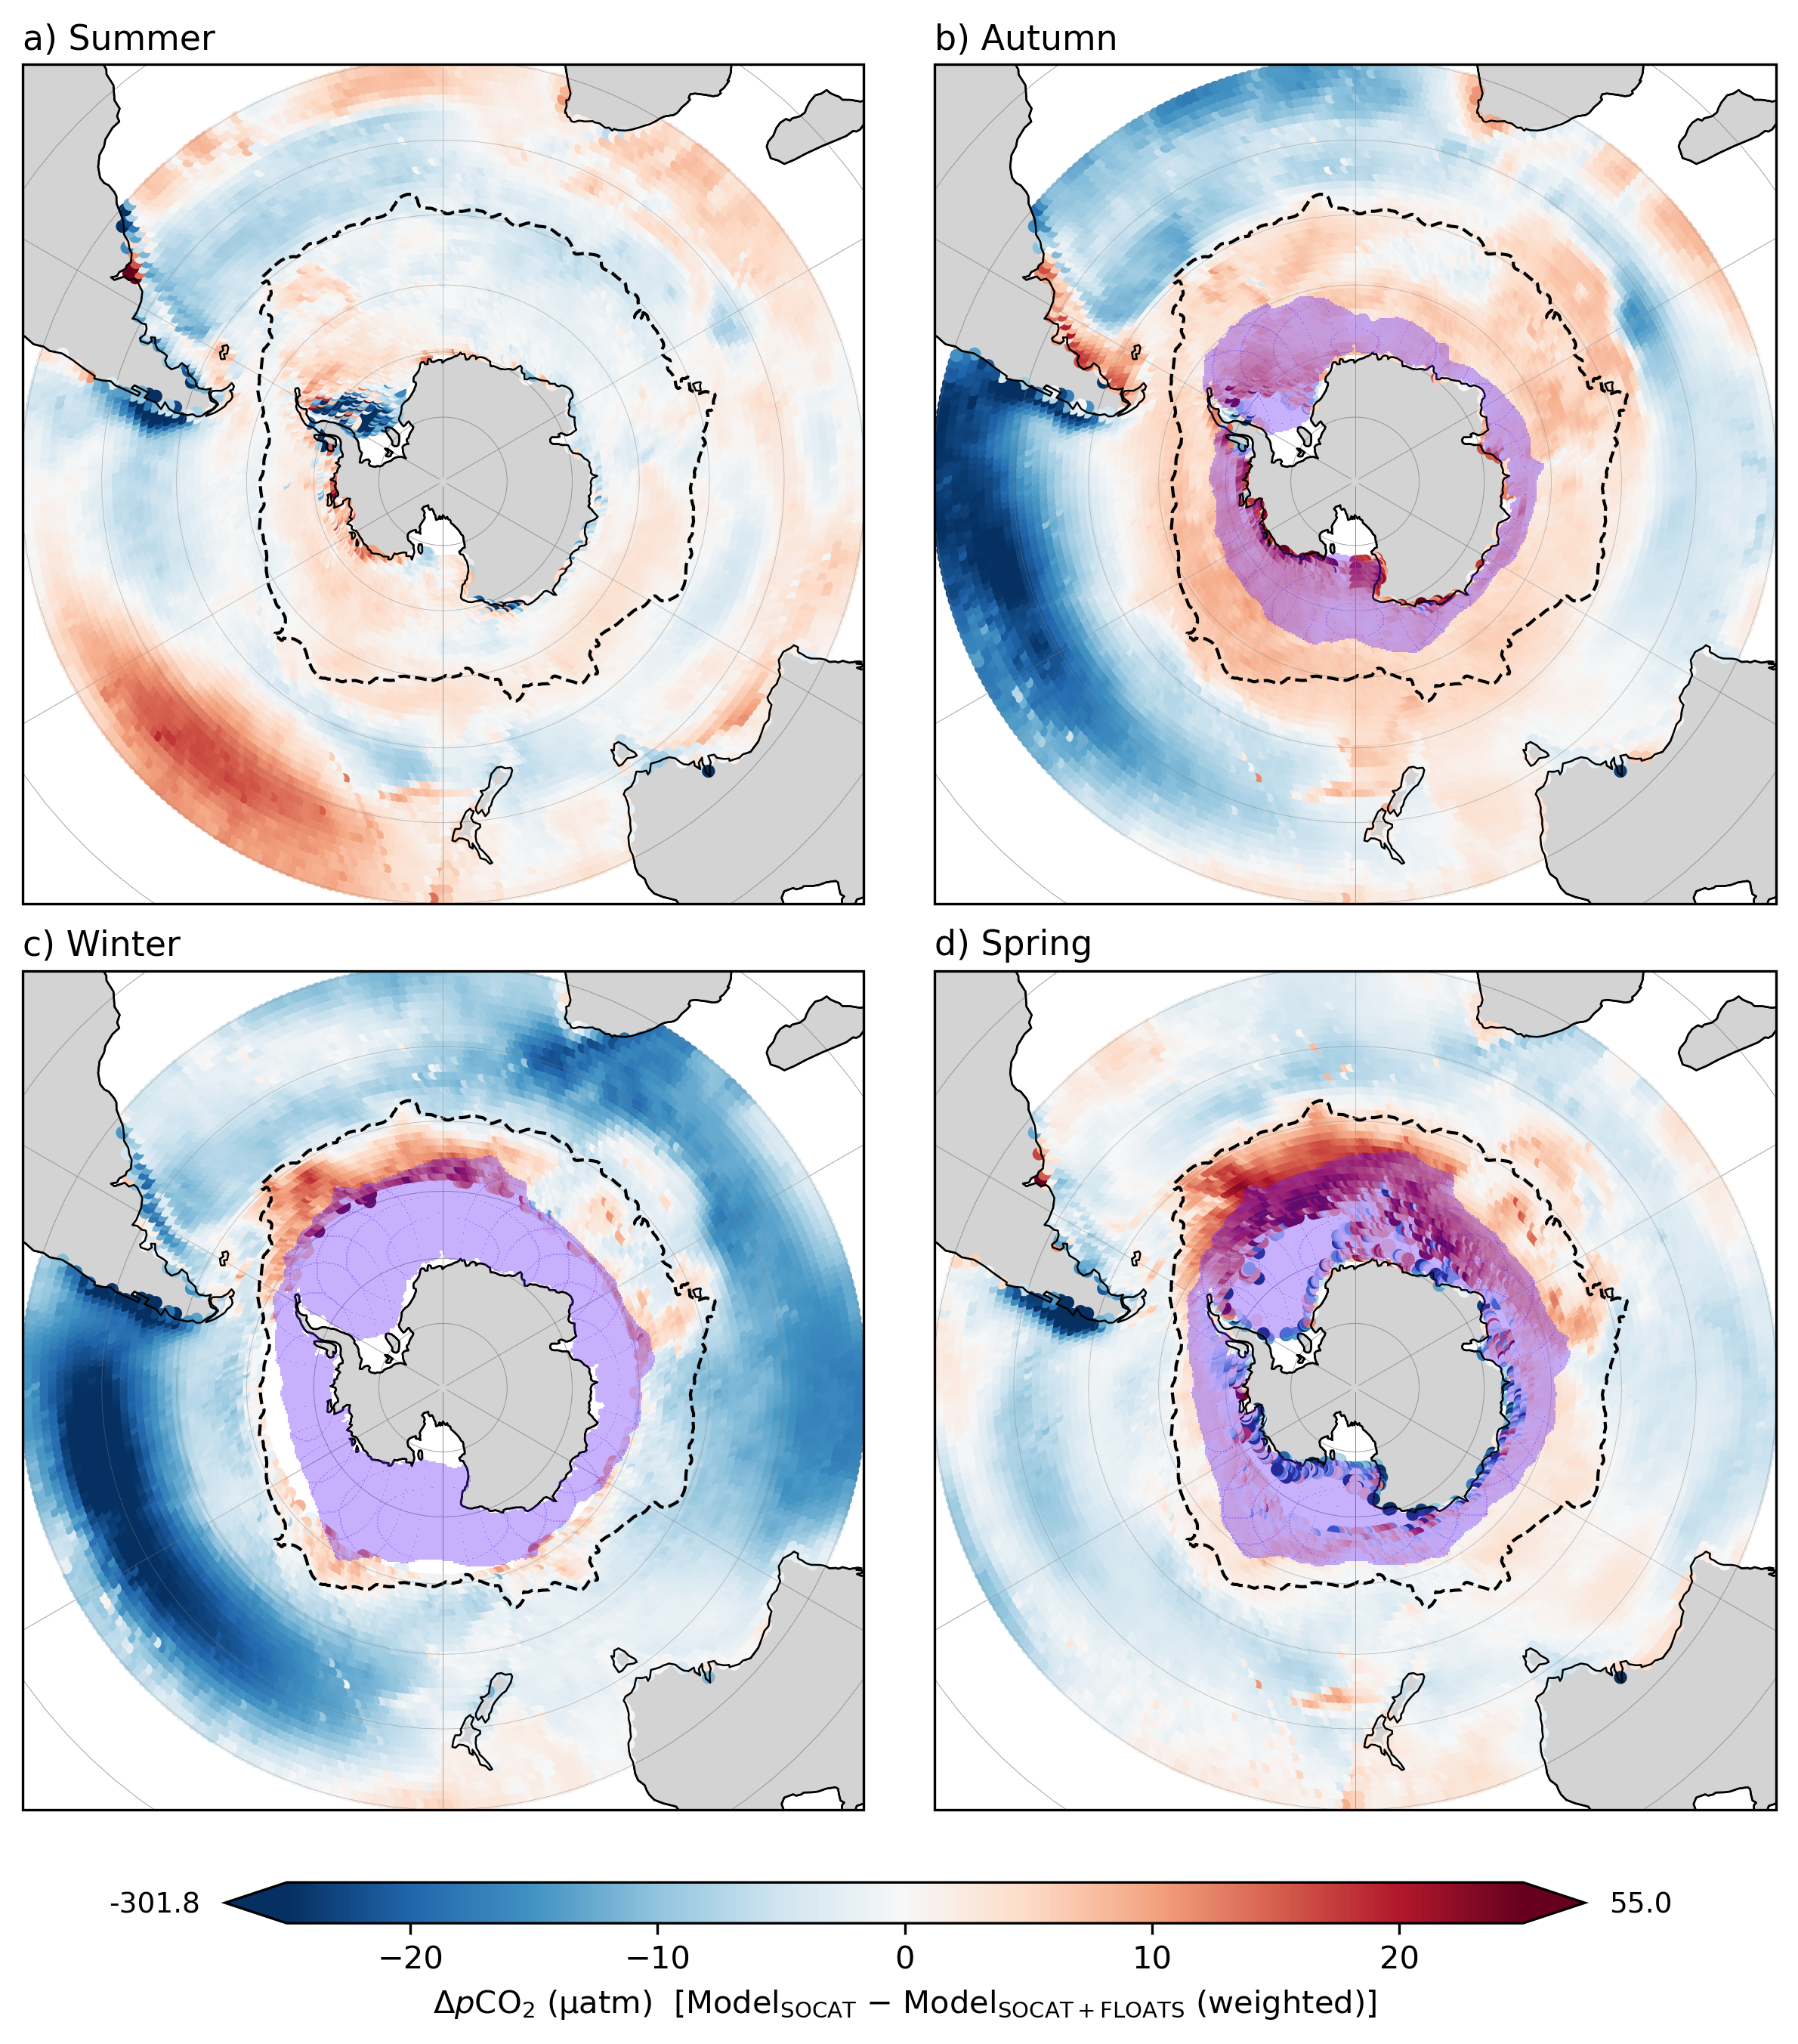

In [14]:
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from matplotlib.colors import Normalize, ListedColormap

# ============================================================
# LOAD DATA
# ============================================================

fronts = xr.load_dataset(
    "/remote/unity/bgc-output/DELAIGUE/SOCAT-FLOATS-OSSE/data/fronts/62985.nc"
)

# Monthly sea-ice climatology DataArray (dims: month, yc, xc; units: percent)
seaice = xr.load_dataset("/remote/unity/bgc-output/DELAIGUE/SOCAT-FLOATS-OSSE/data/fronts/sic_climatology_stats_sh_1991-2020.nc")
seaice_mmean = seaice.mmean


# ============================================================
# HELPERS: Orsi fronts plotting (handles 0..360 lon, NaNs, dateline jumps)
# ============================================================

def lon360_to_lon180(lon):
    lon = np.asarray(lon)
    return ((lon + 180) % 360) - 180

def plot_front_line(ax, lon, lat, *, jump_deg=20, **plot_kwargs):
    """
    Plot a front polyline safely on a global/polar map:
      - drops NaNs
      - converts lon 0..360 -> -180..180
      - splits line where longitude jumps (dateline / gaps) to avoid long chords
    """
    lon = np.asarray(lon).astype(float)
    lat = np.asarray(lat).astype(float)

    m = np.isfinite(lon) & np.isfinite(lat)
    lon = lon[m]
    lat = lat[m]

    lon = lon360_to_lon180(lon)
    if lon.size < 2:
        return

    dlon = np.abs(np.diff(lon))
    breaks = np.where(dlon > jump_deg)[0] + 1
    idxs = np.concatenate(([0], breaks, [lon.size]))

    for a, b in zip(idxs[:-1], idxs[1:]):
        if b - a < 2:
            continue
        ax.plot(
            lon[a:b], lat[a:b],
            transform=ccrs.PlateCarree(),
            **plot_kwargs
        )


# ============================================================
# HELPERS: Sea-ice seasonal MAX mask (ice-only fill, no contours)
# ============================================================

SEASON_TO_MONTHS = {
    "DJF": [12, 1, 2],
    "MAM": [3, 4, 5],
    "JJA": [6, 7, 8],
    "SON": [9, 10, 11],
}

def seasonal_max_from_monthly_clim(seaice_mmean, season):
    """
    Returns 2D seasonal MAX (grid-cell-wise) across the 3 months in the season.
    seaice_mmean values are percent (0..100).
    """
    months = SEASON_TO_MONTHS[season]
    return seaice_mmean.sel(month=months).max("month", skipna=True)

ICE_CMAP = ListedColormap(["#601ef9"])  # soft purple

def plot_ice_mask_seasonal_max_iceonly(
    ax,
    seaice_mmean,
    season,
    *,
    threshold_percent=15.0,
    alpha=0.35,
    zorder=12
):
    """
    Plot ONLY the ice cells (>= threshold_percent) as a yellow semi-transparent mask.
    Non-ice is NaN => fully transparent (avoids the 'purple polygon' footprint).
    Uses the seasonal MAX across the 3 months.
    """
    sic_max = seasonal_max_from_monthly_clim(seaice_mmean, season)

    lon2d = sic_max["lon"].values
    lat2d = sic_max["lat"].values

    ice = (sic_max.values >= threshold_percent)
    ice_only = np.where(ice, 1.0, np.nan)  # only ice plotted

    ax.pcolormesh(
        lon2d, lat2d, ice_only,
        transform=ccrs.PlateCarree(),
        shading="auto",
        cmap=ICE_CMAP,
        vmin=0, vmax=1,
        alpha=alpha,
        zorder=zorder
    )


# ============================================================
# PLOTTING FUNCTION (4 SEASONS)
# ============================================================

def plot_seasonal_difference_maps(
    df_seasonal,
    title_prefix,
    output_path,
    fronts=None,
    seaice_mmean=None,
    ice_threshold_percent=15.0,
    ice_alpha=0.35
):

    # Southern Hemisphere season order + labels
    season_order  = ["DJF", "MAM", "JJA", "SON"]
    season_labels = {
        "DJF": "Summer",
        "MAM": "Autumn",
        "JJA": "Winter",
        "SON": "Spring",
    }

    panel_letters = ["a", "b", "c", "d"]

    vmax = np.nanpercentile(np.abs(df_seasonal["delta_pco2"].values), 99)
    vmin = -vmax
    norm = Normalize(vmin=vmin, vmax=vmax)
    cmap = "RdBu_r"
    true_max = np.nanmax(df_seasonal["delta_pco2"].values)
    true_min = np.nanmin(df_seasonal["delta_pco2"].values)

    fig, axs = plt.subplots(
        2, 2,
        figsize=(10, 10),
        dpi=300,
        subplot_kw={"projection": ccrs.SouthPolarStereo()}
    )

    fig.subplots_adjust(hspace=0.08, wspace=0.08)
    axs = axs.flatten()

    for i, (ax, season) in enumerate(zip(axs, season_order)):

        ax.set_extent([-180, 180, -90, -30], crs=ccrs.PlateCarree())

        # Base map
        ax.coastlines(resolution="110m", linewidth=0.6)
        ax.add_feature(cfeature.LAND, facecolor="lightgray", zorder=0)
        ax.gridlines(draw_labels=False, linewidth=0.2, color="gray", alpha=0.5)

        df_s = df_seasonal[df_seasonal["season"] == season]

        # Main scatter
        sc = ax.scatter(
            df_s["longitude"],
            df_s["latitude"],
            c=df_s["delta_pco2"],
            s=10,
            cmap=cmap,
            norm=norm,
            transform=ccrs.PlateCarree(),
            zorder=2
        )

        # ------------------------------------------------------------
        # OVERLAY: Sea-ice presence mask (JJA + MAM + SON)
        # ------------------------------------------------------------
        if seaice_mmean is not None and season in {"MAM", "JJA", "SON"}:
            plot_ice_mask_seasonal_max_iceonly(
                ax,
                seaice_mmean,
                season,
                threshold_percent=ice_threshold_percent,
                alpha=ice_alpha,
                zorder=12
            )
        # ------------------------------------------------------------
        # OVERLAY: Orsi Polar Front (PF)
        # ------------------------------------------------------------
        if fronts is not None:
            plot_front_line(
                ax,
                fronts["LonPF"].values,
                fronts["LatPF"].values,
                jump_deg=20,
                linewidth=1.0,
                linestyle="--",
                color="k",
                zorder=15
            )

        # Features on top
        ax.add_feature(cfeature.LAND, facecolor="none", edgecolor="none", zorder=8)

        ax.gridlines(
            draw_labels=False,
            linewidth=0.2,
            color="gray",
            alpha=0.5,
            zorder=9
        )

        ax.coastlines(resolution="110m", linewidth=0.6, zorder=10)

        # Panel label
        ax.text(
            0, 1.05,
            f"{panel_letters[i]}) {season_labels[season]}",
            transform=ax.transAxes,
            ha="left",
            va="top",
            fontsize=11,
        )

    # ============================================================
    # COLORBAR
    # ============================================================
    cax = fig.add_axes([0.215, 0.06, 0.60, 0.018])

    cbar = fig.colorbar(sc, cax=cax, orientation="horizontal", extend="both")
    cbar.set_label(
        r"$\Delta p$CO$_2$ (µatm)  [Model$_{\mathrm{SOCAT}}$ − Model$_{\mathrm{SOCAT+FLOATS}}$ (weighted)]"
    )

    cbar.ax.text(
        -0.07, 0.45, f"{true_min:.1f}",
        transform=cbar.ax.transAxes, va="center", ha="right", fontsize=9
    )
    cbar.ax.text(
        1.07, 0.45, f"{true_max:.1f}",
        transform=cbar.ax.transAxes, va="center", ha="left", fontsize=9
    )

    plt.savefig(output_path, dpi=300, bbox_inches="tight")
    plt.show()


# ============================================================
# CALL
# ============================================================

plot_seasonal_difference_maps(
    df_seasonal,
    "SOCAT − Combined weighted predictions",
    "/remote/unity/bgc-output/DELAIGUE/SOCAT-FLOATS-OSSE/figs/"
    "Fig7.png",
    fronts=fronts,
    seaice_mmean=seaice_mmean,
    ice_threshold_percent=15.0,  # 15% is the standard "extent" threshold
    ice_alpha=0.35               
)
